# Case Study 3: Detecting Generator Usage from Sensor Data 

# Problem Statement

Many hospitals in sub-Saharan Africa rely on multiple power sources — typically grid electricity, generators, and solar. However, identifying which source is active at any given time is not straightforward. 

The goal of this case study is to **detect the active power source** (grid, solar, or generator) at each time window using sensor data that includes voltage and frequency readings taken every 2 minutes. 

We have access to:
- The current rule-based classification of power source usage (used as a reference or "ground truth")
- Raw time-series voltage and frequency data collected by sensors installed in hospital rooms
- Known power source configurations per room



## 1. DATA CLEANING AND WRANGLING


Before we can analyze or model the data, we need to make sure it is **clean, consistent, and structured** properly. This process is known as **data cleaning and wrangling**.

In this section, we will:
- **Inspect the dataset** to understand its structure and contents
- **Handle missing values**, duplicates, or invalid entries
- **Fix data types** (e.g., make sure timestamps are datetime objects)
- **Rename or standardize column names** for clarity
- **Filter out irrelevant data** or focus on key subsets (e.g., only rooms with complete power source info)

The goal is to make the dataset **analysis-ready** so we can confidently explore patterns and relationships in the next step (EDA).


### Inspecting the dataset

In [115]:
import pandas as pd
import numpy as np

In [11]:
df=pd.read_csv("sierra-leone_power_source_2023-2024.csv")

/var/folders/z2/qn6brxnj2hq86_bnc891ljkw0000gn/T/ipykernel_46319/2392275839.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("sierra-leone_power_source_2023-2024.csv")


In [12]:
df.head(5)

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est
0,2023-07-22 20:42:03,BBFDA35A,Main drug store - Solar w/Grid Backup,hastings,221.357850,99.940036,Solar w/Grid Backup,unknown
1,2023-07-23 06:58:03,BBFDA35A,Main drug store - Solar w/Grid Backup,hastings,221.357850,99.790440,Solar w/Grid Backup,unknown
2,2023-07-23 13:46:03,BBFDA35A,Main drug store - Solar w/Grid Backup,hastings,221.357850,99.920064,Solar w/Grid Backup,unknown
3,2023-07-23 23:34:03,BBFDA35A,Main drug store - Solar w/Grid Backup,hastings,217.114569,49.957536,Solar w/Grid Backup,solar
4,2023-07-24 00:18:03,BBFDA35A,Main drug store - Solar w/Grid Backup,hastings,219.943423,50.017506,Solar w/Grid Backup,solar


In [13]:
df.columns

Index(['time', 'respondent_id', 'room', 'hospital', 'voltage', 'frequency',
       'power_source', 'power_source_est'],
      dtype='object')

## Column Descriptions

| Column Name         | Description                                                                 |
|---------------------|-----------------------------------------------------------------------------|
| `time`              | Timestamp when the reading was recorded (every 2 minutes)                   |
| `respondent_id`     | Unique identifier for the sensor or room being monitored                    |
| `room`              | Name or type of room, includes info about its power configuration           |
| `hospital`          | Name of the hospital where the sensor is located                            |
| `voltage`           | Voltage reading captured by the sensor                                      |
| `frequency`         | Frequency reading captured by the sensor                                    |
| `power_source`      | Known power configuration for the room (e.g., "Solar w/Grid Backup")        |
| `power_source_est`  | Estimated active power source detected by the current rule-based algorithm  |


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7982001 entries, 0 to 7982000
Data columns (total 8 columns):
 #   Column            Dtype  
---  ------            -----  
 0   time              object 
 1   respondent_id     object 
 2   room              object 
 3   hospital          object 
 4   voltage           float64
 5   frequency         float64
 6   power_source      object 
 7   power_source_est  object 
dtypes: float64(2), object(6)
memory usage: 487.2+ MB


In [15]:
df['hospital'].value_counts()

hospital
princess_christian    1579080
ola_during            1250320
masanga                936438
kambia                 800885
kabala                 576153
wilberforce            563562
connaught              504474
bonthe                 439828
hastings               413253
king_harman_road       331501
magburaka              298222
makeni                 288285
Name: count, dtype: int64

In [16]:
df['hospital'].nunique()

12

In [17]:
df['respondent_id'].unique()

array(['BBFDA35A', '76B32C6A', 'CD9B9362', '36291A37', '3393AD1E',
       '7A696BB0', '880B12A1', 'AE9D9E66', 'A45DEF14', 'BC894308',
       '19906B6E', '11FE9C82', 'CA7A6C34', 'DF4F22FC', 'E8434F58',
       '95E7399D', '274B46C5', '41570E47', '358F181D', '904166BE',
       '10DA907C', '31581AC3', 'E76A2F18', '285A769C', '9F7BB66B',
       'F818DD2C', 'A7081050', 'B391847B', '10EB0F63', '0BB96209',
       'E3670099', '31AA625C', '1F697CD8', '311723D1', '74901A6B',
       '40101E61', 4.0101e+65, '23D03AB0', '30314B82', 'A81CB141',
       '7591C426', 'B527FBF1', '293BAF37', '9FD654ED', 'D921F34C',
       '2ACA9DDB', 'F3CB5A87', '65E8690F', 'E87ED98B', '37B7AE20',
       '42D5AFD3', '794A4021', '8EC84D98', '42742A0F', '3EA83577',
       '843F45D0', 'A4DD6DF3', '86ABF063', '23C03747', '181DEF5E',
       'F31FD6DB', 'C0FE9DB4', 'DD49499C', '7CF431FF', '8DF9A946',
       'CE9340E1'], dtype=object)

In [18]:
df['room'].nunique()

61

In [19]:
df['room'].value_counts()

room
Step down ward two - Grid w/Solar & Generator Backup     482690
Ward 2 - Grid w/Solar Backup                             424482
HDU - Grid w/Solar & Generator Backup                    261496
Administration Building - Solar & Generator              253868
Operating Theatre - Grid w/Solar & Generator Backup      251186
                                                          ...  
HOD Maintenance Office - Grid w/Solar Backup              38757
Maternity labour room  - Grid                             27728
Maintenance Office  - Grid w/Solar & Generator Backup     23576
High Denpendency Unit - Solar w/Grid Backup               12939
Female ward - Generator                                    5486
Name: count, Length: 61, dtype: int64

In [20]:

df_rooms = df[['room', 'power_source']]
df_rooms.head()

,room,power_source
0,Main drug store - Solar w/Grid Backup,Solar w/Grid Backup
1,Main drug store - Solar w/Grid Backup,Solar w/Grid Backup
2,Main drug store - Solar w/Grid Backup,Solar w/Grid Backup
3,Main drug store - Solar w/Grid Backup,Solar w/Grid Backup
4,Main drug store - Solar w/Grid Backup,Solar w/Grid Backup


In [21]:
df['power_source'].value_counts()

power_source
Solar & Generator                  2299903
Grid w/Solar & Generator Backup    1982694
Grid w/Generator Backup            1334702
Grid                                682977
Grid w/Solar Backup                 678046
Solar w/Grid Backup                 550278
Solar                               447915
Generator                             5486
Name: count, dtype: int64

In [22]:
df['power_source'].nunique()

8

In [23]:
df['power_source_est'].value_counts()

power_source_est
grid                 3975373
solar                2872932
generator             746609
unknown               245647
power_conditioner     141440
Name: count, dtype: int64

In [24]:
df['power_source_est'].unique()

array(['unknown', 'solar', 'grid', 'generator', 'power_conditioner'],
      dtype=object)

In [25]:
df.shape

(7982001, 8)

### Handling Missing values

In [26]:
df.isnull().sum()

time                0
respondent_id       0
room                0
hospital            0
voltage             0
frequency           0
power_source        0
power_source_est    0
dtype: int64

There are no missing values in the data, we will just need to hadle the data types and values relating to our goal

### Fixing data types

- changing time to datetime datatype

In [27]:
df['time']=pd.to_datetime(df['time'])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7982001 entries, 0 to 7982000
Data columns (total 8 columns):
 #   Column            Dtype         
---  ------            -----         
 0   time              datetime64[ns]
 1   respondent_id     object        
 2   room              object        
 3   hospital          object        
 4   voltage           float64       
 5   frequency         float64       
 6   power_source      object        
 7   power_source_est  object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 487.2+ MB


- There is one value of the `respondent_id` that is an *float datatype* possibly an error in the sensor id so we are going to replace to an assumed string respondent_id of **40101E65** as opposed to dropping it and loosing the data.

In [29]:
df['respondent_id'].apply(type).value_counts()

respondent_id
<class 'str'>      7850929
<class 'float'>     131072
Name: count, dtype: int64

In [30]:
df[df['respondent_id'].apply(type) == float].value_counts()


time                 respondent_id  room                                 hospital  voltage     frequency  power_source       power_source_est
2023-05-04 12:46:03  4.010100e+65   Emergency room  - Solar & Generator  masanga   226.308345  50.035025  Solar & Generator  solar               1
2023-05-04 12:58:03  4.010100e+65   Emergency room  - Solar & Generator  masanga   226.308345  49.977510  Solar & Generator  solar               1
2023-12-25 21:56:03  4.010100e+65   Emergency room  - Solar & Generator  masanga   225.601132  50.007501  Solar & Generator  solar               1
2023-12-25 21:54:03  4.010100e+65   Emergency room  - Solar & Generator  masanga   230.551627  49.972515  Solar & Generator  solar               1
2023-12-25 21:52:03  4.010100e+65   Emergency room  - Solar & Generator  masanga   229.844413  50.040032  Solar & Generator  solar               1
                                                                                                                           

In [31]:
#Converting all ID's to string values for consistency
df['respondent_id']=df['respondent_id'].astype(str)


In [32]:
df['respondent_id'].apply(type).value_counts()

respondent_id
<class 'str'>    7982001
Name: count, dtype: int64

In [33]:
#Replacing the corrupted ID
df.loc[df['respondent_id'] == '4.0101e+65', 'respondent_id'] = '40101E65'

In [34]:
df['respondent_id'].nunique()

66

- Checking Duplicates

In [35]:
df.duplicated().sum()

0

- The room column has room + power source mapping which is a bit duplicated, so I want to change the rooms to be solely rooms and their distinct power source on the power_source columns.

In [36]:
df_rooms.sample(5)

,room,power_source
7559661,Intensive Care Unit - Grid w/Solar & Generator...,Grid w/Solar & Generator Backup
7015879,Operating theatre room - Solar & Generator,Solar & Generator
4627847,Emergency room - Solar & Generator,Solar & Generator
1473599,SCBU WARD - Solar,Solar
2981759,Step down ward two - Grid w/Solar & Generator ...,Grid w/Solar & Generator Backup


In [37]:
df['room'] = df['room'].str.split('-').str[0].str.strip()

In [38]:
df['room'].sample(10)

946070                    SBCU Ward
5444725                  Drug store
4116085                      Ward 2
1139571      Special Baby Care ward
7397256         Paediatric pharmacy
2607480     Administration Building
5844268    Operating Theatre Office
6051156           Operating Theatre
1426429                   SCBU WARD
4736305              Emergency room
Name: room, dtype: object

In [39]:
df['room'].value_counts()

room
Step down ward two                            482690
Ward 2                                        424482
HDU                                           357585
Special Baby Care ward                        322379
Administration Building                       253868
Operating Theatre                             251186
SCBU WARD                                     243119
Emergency room                                241133
Labour ward/Maternity                         238112
Surgical ward                                 230296
Medical Superintendent Office                 229470
D.M.S2                                        214807
Operation theatre                             211141
Paediatric/Resuscitation Room                 207152
Intensive Care Unit                           201679
General  medical store                        195171
Power Change Over Room                        187068
Drug store                                    180049
Labour                                   

In [40]:
#What we have so far

df.head(10)

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est
0,2023-07-22 20:42:03,BBFDA35A,Main drug store,hastings,221.357850,99.940036,Solar w/Grid Backup,unknown
1,2023-07-23 06:58:03,BBFDA35A,Main drug store,hastings,221.357850,99.790440,Solar w/Grid Backup,unknown
2,2023-07-23 13:46:03,BBFDA35A,Main drug store,hastings,221.357850,99.920064,Solar w/Grid Backup,unknown
3,2023-07-23 23:34:03,BBFDA35A,Main drug store,hastings,217.114569,49.957536,Solar w/Grid Backup,solar
4,2023-07-24 00:18:03,BBFDA35A,Main drug store,hastings,219.943423,50.017506,Solar w/Grid Backup,solar
5,2023-07-25 11:40:03,BBFDA35A,Main drug store,hastings,219.236209,50.032521,Solar w/Grid Backup,solar
6,2023-07-26 06:56:03,BBFDA35A,Main drug store,hastings,215.700141,49.992501,Solar w/Grid Backup,solar
7,2023-07-26 07:36:03,BBFDA35A,Main drug store,hastings,219.236209,49.965024,Solar w/Grid Backup,solar
8,2023-07-26 18:06:03,BBFDA35A,Main drug store,hastings,214.992928,50.010002,Solar w/Grid Backup,solar
9,2023-07-26 21:12:06,BBFDA35A,Main drug store,hastings,212.871287,50.037528,Solar w/Grid Backup,solar


- Rounding of the values of Voltage and frequency to 4 decimal places for consistency

In [32]:
df['voltage'] = df['voltage'].round(4)

df['frequency'] = df['frequency'].round(4)

In [41]:
df.head(5)

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est
0,2023-07-22 20:42:03,BBFDA35A,Main drug store,hastings,221.357850,99.940036,Solar w/Grid Backup,unknown
1,2023-07-23 06:58:03,BBFDA35A,Main drug store,hastings,221.357850,99.790440,Solar w/Grid Backup,unknown
2,2023-07-23 13:46:03,BBFDA35A,Main drug store,hastings,221.357850,99.920064,Solar w/Grid Backup,unknown
3,2023-07-23 23:34:03,BBFDA35A,Main drug store,hastings,217.114569,49.957536,Solar w/Grid Backup,solar
4,2023-07-24 00:18:03,BBFDA35A,Main drug store,hastings,219.943423,50.017506,Solar w/Grid Backup,solar


- Since `power_source_est` is our target column, We can remove the **"unknown"** value so we can have clean data to use with specific targets of our intended sources which is solar,grid or generator

__ignoring this for now__ We will make a more objective decision based on the datapoints we have.

In [42]:
# df = df[df['power_source_est'] != 'unknown']
# df['power_source_est'].value_counts()

*Ask about the power conditioner, is it a power source to focus on?

### Data Cleaning & Wrangling Summary

- Converted `time` to datetime format

- Cleaned `respondent_id`, fixing a corrupted ID (`4.0101e+65`) to `40101E65`

- Removed duplicate power source info from the `room` column (e.g., "Operation theatre - Solar & Generator" → "Operation theatre")

- Verified no missing values or duplicate rows

- Rounded `voltage` and `frequency` to 4 decimal places for consistency

- ~~Removed rows with `power_source_est` = "unknown" to focus on valid target classes~~

In [43]:
df.reset_index(drop=True, inplace=True)

In [44]:
df.head(5)

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est
0,2023-07-22 20:42:03,BBFDA35A,Main drug store,hastings,221.357850,99.940036,Solar w/Grid Backup,unknown
1,2023-07-23 06:58:03,BBFDA35A,Main drug store,hastings,221.357850,99.790440,Solar w/Grid Backup,unknown
2,2023-07-23 13:46:03,BBFDA35A,Main drug store,hastings,221.357850,99.920064,Solar w/Grid Backup,unknown
3,2023-07-23 23:34:03,BBFDA35A,Main drug store,hastings,217.114569,49.957536,Solar w/Grid Backup,solar
4,2023-07-24 00:18:03,BBFDA35A,Main drug store,hastings,219.943423,50.017506,Solar w/Grid Backup,solar


In [45]:
df.to_csv("sierra-leone_power_source_2023-2024_clean.csv",index=False)

# 2. EXPLANATORY DATA ANALYSIS

The goal of this section is to explore the cleaned dataset to understand trends, patterns, and relationships that can inform future modeling.

We will focus on:
- Understanding the distribution and behavior of voltage and frequency
- Exploring how power sources vary over time (hour of day, day of week)
- Looking for patterns or correlations between features and the target **power_source_est**
- Identifying anything unexpected or interesting that may affect feature engineering or modeling later

This step helps us generate hypotheses, spot issues, and design better machine learning models in the next phase.

In [46]:
clean_df=pd.read_csv('sierra-leone_power_source_2023-2024_clean.csv')

/var/folders/z2/qn6brxnj2hq86_bnc891ljkw0000gn/T/ipykernel_46319/246121620.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  clean_df=pd.read_csv('sierra-leone_power_source_2023-2024_clean.csv')


In [47]:
clean_df['time'] = pd.to_datetime(df['time'])

In [48]:
clean_df.head(10)

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est
0,2023-07-22 20:42:03,BBFDA35A,Main drug store,hastings,221.357850,99.940036,Solar w/Grid Backup,unknown
1,2023-07-23 06:58:03,BBFDA35A,Main drug store,hastings,221.357850,99.790440,Solar w/Grid Backup,unknown
2,2023-07-23 13:46:03,BBFDA35A,Main drug store,hastings,221.357850,99.920064,Solar w/Grid Backup,unknown
3,2023-07-23 23:34:03,BBFDA35A,Main drug store,hastings,217.114569,49.957536,Solar w/Grid Backup,solar
4,2023-07-24 00:18:03,BBFDA35A,Main drug store,hastings,219.943423,50.017506,Solar w/Grid Backup,solar
5,2023-07-25 11:40:03,BBFDA35A,Main drug store,hastings,219.236209,50.032521,Solar w/Grid Backup,solar
6,2023-07-26 06:56:03,BBFDA35A,Main drug store,hastings,215.700141,49.992501,Solar w/Grid Backup,solar
7,2023-07-26 07:36:03,BBFDA35A,Main drug store,hastings,219.236209,49.965024,Solar w/Grid Backup,solar
8,2023-07-26 18:06:03,BBFDA35A,Main drug store,hastings,214.992928,50.010002,Solar w/Grid Backup,solar
9,2023-07-26 21:12:06,BBFDA35A,Main drug store,hastings,212.871287,50.037528,Solar w/Grid Backup,solar


In [49]:
clean_df.sample(20)

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est
4612073,2024-02-10 15:02:03,4010100000000000275150233739695024981234640191...,Emergency room,masanga,224.893918,50.035025,Solar & Generator,solar
7853065,2023-06-14 02:16:03,8DF9A946,Intensive Care Unit,ola_during,233.380481,49.736397,Grid w/Solar & Generator Backup,grid
487541,2023-06-02 13:30:03,36291A37,Step down ward two,ola_during,229.844413,50.010002,Grid w/Solar & Generator Backup,solar
281108,2023-12-31 10:06:03,CD9B9362,Medical Superintendent Office,kabala,230.551627,49.995000,Solar & Generator,solar
2429373,2024-03-27 03:12:03,904166BE,SBCU Ward,makeni,213.578501,49.905180,Grid w/Generator Backup,grid
2346956,2023-11-11 13:30:03,358F181D,HOD (Office),princess_christian,234.794908,50.579131,Solar w/Grid Backup,unknown
7657102,2023-10-12 17:54:14,8DF9A946,Intensive Care Unit,ola_during,239.038190,50.092671,Grid w/Solar & Generator Backup,grid
6251937,2023-05-24 12:12:03,37B7AE20,Operating Theatre,princess_christian,239.038190,49.556470,Grid w/Solar & Generator Backup,grid
7576813,2023-06-11 23:14:03,8DF9A946,Intensive Care Unit,ola_during,232.673267,50.027515,Grid w/Solar & Generator Backup,grid
7713368,2024-03-26 03:24:06,7CF431FF,Labour,princess_christian,229.844413,49.990002,Grid w/Solar & Generator Backup,grid


In [50]:
clean_df.describe(exclude='object')

,time,voltage,frequency
count,7982001,7.982001e+06,7.982001e+06
mean,2023-11-28 13:11:28.933962240,2.293505e+02,5.062532e+01
min,2023-05-01 00:00:03,7.072136e-01,3.003815e+01
25%,2023-08-27 00:22:03,2.248939e+02,4.996752e+01
50%,2023-12-17 01:14:03,2.312588e+02,5.002501e+01
75%,2024-03-02 01:02:03,2.362093e+02,5.019324e+01
max,2024-04-30 23:58:15,3.917963e+02,1.000000e+02
std,NaN,1.354834e+01,5.289033e+00


In [51]:
time_coverage = clean_df.groupby('hospital')['time'].agg(['min', 'max']).reset_index()

print(time_coverage)

              hospital                 min                 max
0               bonthe 2023-05-15 09:00:37 2024-04-30 23:58:03
1            connaught 2024-01-18 11:22:03 2024-04-30 23:58:03
2             hastings 2023-07-20 18:42:03 2024-04-30 23:58:15
3               kabala 2023-05-12 12:23:49 2024-04-30 23:58:03
4               kambia 2023-05-03 12:10:03 2024-04-30 23:58:03
5     king_harman_road 2024-01-19 18:14:03 2024-04-30 23:58:03
6            magburaka 2024-02-01 05:36:03 2024-04-30 23:58:04
7               makeni 2024-02-01 05:20:09 2024-04-30 23:58:03
8              masanga 2023-05-04 12:36:03 2024-04-30 23:58:03
9           ola_during 2023-05-01 00:00:03 2024-04-30 23:58:04
10  princess_christian 2023-05-01 00:00:03 2024-04-30 23:58:06
11         wilberforce 2023-06-15 18:16:03 2024-04-30 17:52:08


In [52]:
#Excluding the power conditioner for now
clean_df = clean_df[clean_df['power_source_est'] != 'power_conditioner']

In [53]:
clean_df['power_source_est'].value_counts(normalize=True)*100

power_source_est
grid         50.702660
solar        36.641919
generator     9.522393
unknown       3.133028
Name: proportion, dtype: float64

- grid is the most common source, followed by solar then generator

## Visualisations

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
hospital_dist = (
    clean_df.groupby(['hospital', 'power_source'])
    .size()
    .reset_index(name='count')
)

In [55]:
hospital_dist['percentage'] = hospital_dist.groupby('hospital')['count'].transform(lambda x: 100 * x / x.sum())

plt.figure(figsize=(16, 10))
ax = sns.barplot(data=hospital_dist, x='hospital', y='percentage', hue='power_source')

plt.title('Relative Power Source Usage per Hospital')
plt.ylabel('Percentage (%)')
plt.xlabel('Hospital')
plt.xticks(rotation=45)
plt.legend(title='Power Source')
plt.yticks(range(0, 101, 10))

for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


NameError: name 'hospital_dist' is not defined

### Duration of recording data

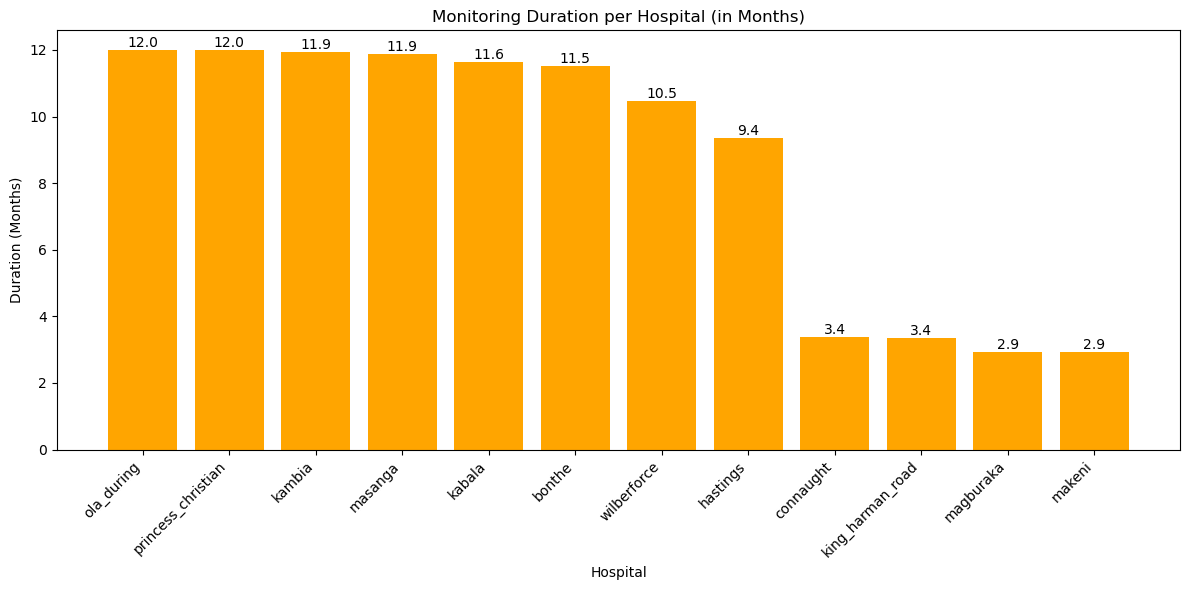

In [ ]:
hospital_time = clean_df.groupby('hospital')['time'].agg(['min', 'max']).reset_index()

hospital_time['duration_days'] = (hospital_time['max'] - hospital_time['min']).dt.days
hospital_time['duration_months'] = hospital_time['duration_days'] / 30.44  # approx. months

hospital_time = hospital_time.sort_values('duration_months', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(hospital_time['hospital'], hospital_time['duration_months'], color='orange')

for bar, months in zip(bars, hospital_time['duration_months']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"{months:.1f}", ha='center', va='bottom', fontsize=10)

plt.title("Monitoring Duration per Hospital (in Months)")
plt.ylabel("Duration (Months)")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This is now using the Estimated power source, grouping the percentage usage of the power source.

In [ ]:
hospital_dist = (
    clean_df.groupby(['hospital', 'power_source_est'])
    .size()
    .reset_index(name='count')
)


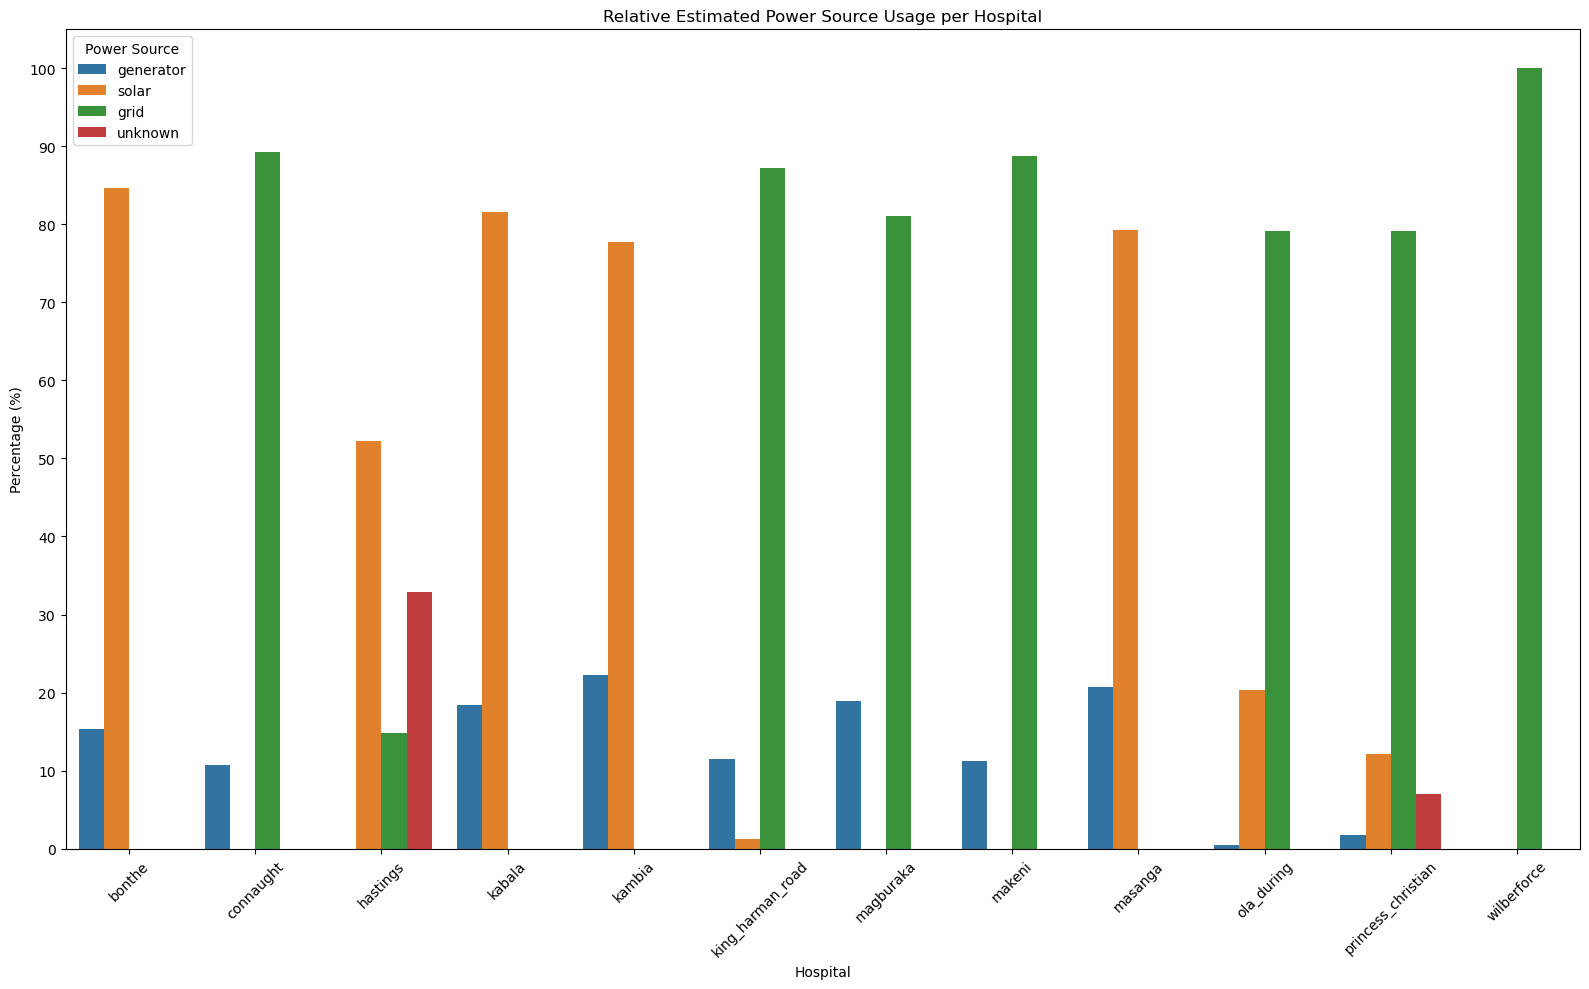

In [ ]:

# Compute percentage within each hospital
hospital_dist['percentage'] = hospital_dist.groupby('hospital')['count'].transform(lambda x: 100 * x / x.sum())

plt.figure(figsize=(16, 10))
sns.barplot(data=hospital_dist, x='hospital', y='percentage', hue='power_source_est')
plt.title('Relative Estimated Power Source Usage per Hospital')
plt.ylabel('Percentage (%)')
plt.xlabel('Hospital')
plt.xticks(rotation=45)
plt.legend(title='Power Source')
plt.tight_layout()
plt.yticks(range(0, 101, 10))
plt.show()


Things to consider:

- What percentage of a hospital's time is spent using grid, solar, or generator?

- Which hospitals rely more heavily on solar or generator?

Distribution of Power Sources

-replacing count with percentatges instead

In [ ]:
power_source_percent = (
    clean_df['power_source']
    .value_counts(normalize=True)
    .rename_axis('power_source')
    .reset_index(name='percent')
)

power_source_percent['percent'] *= 100


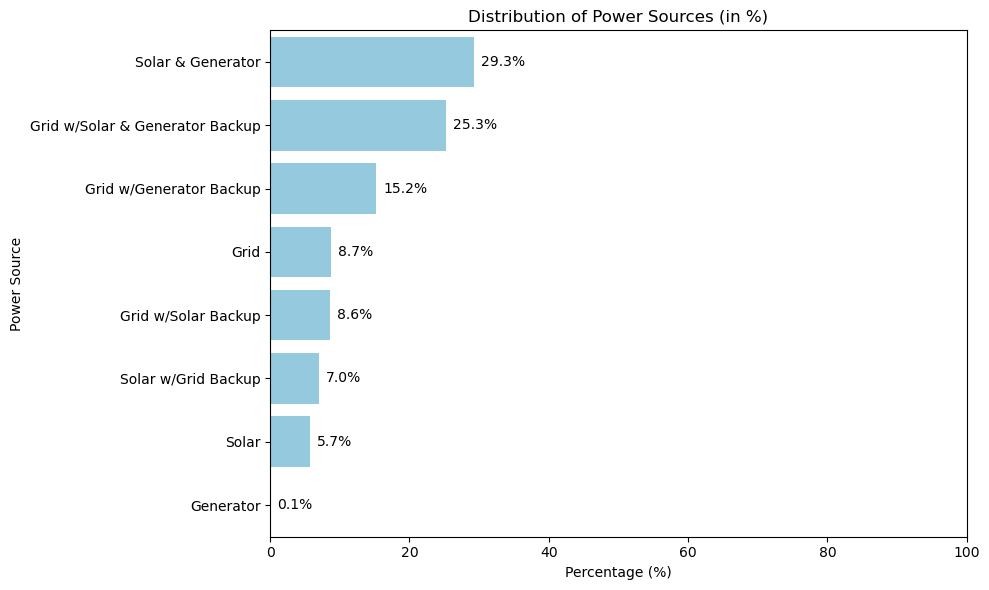

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=power_source_percent,
    y='power_source',
    x='percent',
    color='skyblue'
)

# Annotate percentages on the bars
for i, row in power_source_percent.iterrows():
    ax.text(
        row['percent'] + 1,  # position text slightly after the bar
        i,
        f"{row['percent']:.1f}%",
        va='center'
    )

plt.title('Distribution of Power Sources (in %)')
plt.xlabel('Percentage (%)')
plt.ylabel('Power Source')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


Distribution of Estimated Power Sources

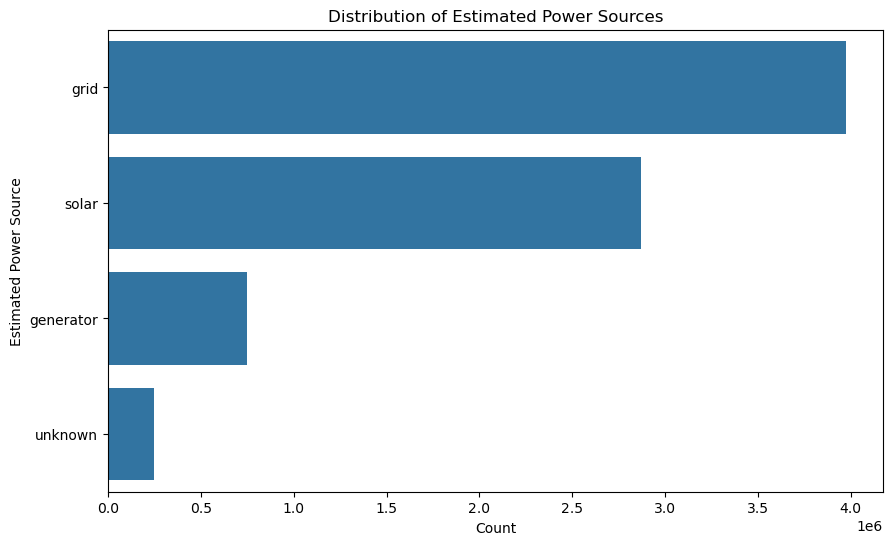

In [56]:
plt.figure(figsize=(10, 6))
sns.countplot(data=clean_df, y='power_source_est', order = clean_df['power_source_est'].value_counts().index)
plt.title('Distribution of Estimated Power Sources')
plt.xlabel('Count')
plt.ylabel('Estimated Power Source')
plt.show()

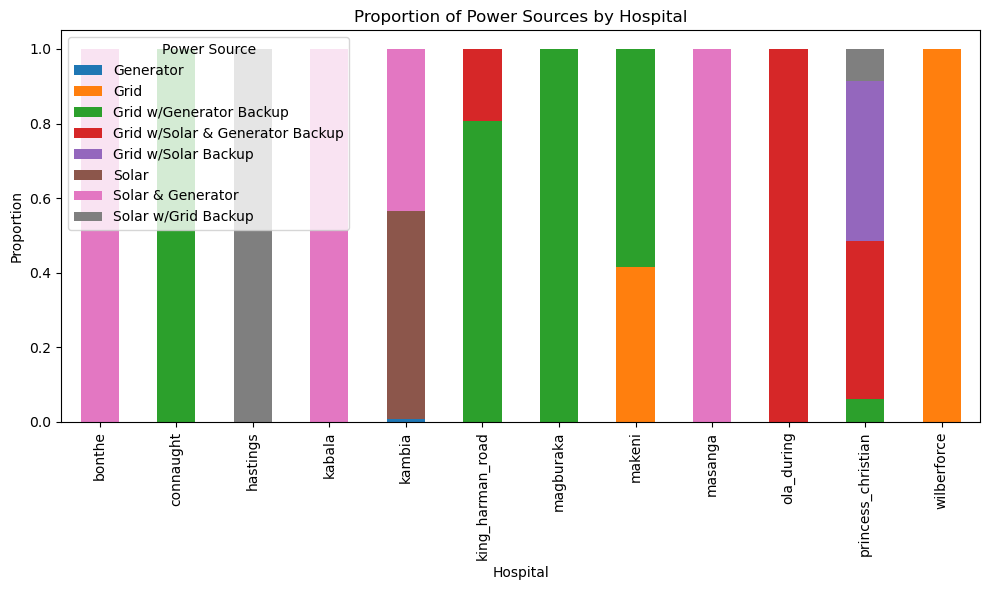

In [57]:
# Proportion of power sources by hospital
hospital_power = clean_df.groupby(['hospital', 'power_source']).size().unstack(fill_value=0)
hospital_power_prop = hospital_power.div(hospital_power.sum(axis=1), axis=0)

hospital_power_prop.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Proportion of Power Sources by Hospital')
plt.ylabel('Proportion')
plt.xlabel('Hospital')
plt.legend(title='Power Source')
plt.tight_layout()
plt.show()

In [58]:
# Proportion of each power source type
power_source_counts = clean_df['power_source'].value_counts(normalize=True)

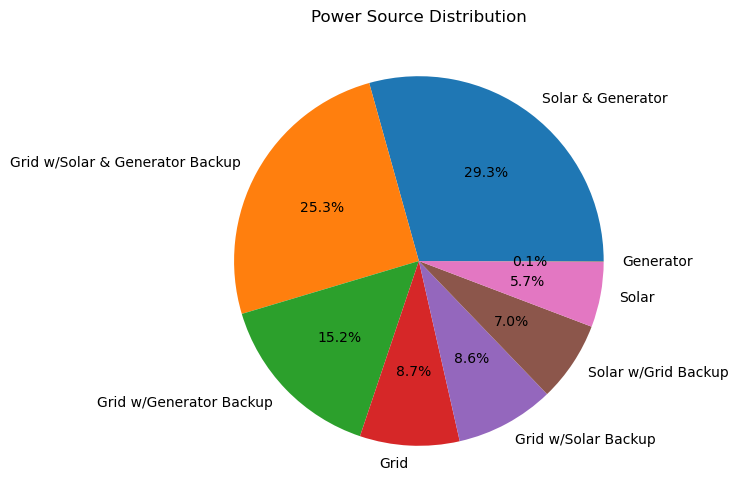

In [59]:
# Pie chart of power source proportions
power_source_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title('Power Source Distribution')
plt.ylabel('')
plt.show()

## Time based visualisations

- Lets start by adding time-based features

In [60]:
# Hour of the day (0–23)
clean_df['hour'] = clean_df['time'].dt.hour


In [61]:
#Weekday name 
clean_df['day_of_week'] = clean_df['time'].dt.day_name()  

In [62]:
clean_df['date'] = clean_df['time'].dt.date 

#### Power Source Usage by Hour of Day

In [64]:
hourly_usage = (
    clean_df.groupby(['hour', 'power_source_est'])
    .size()
    .reset_index(name='count')
)


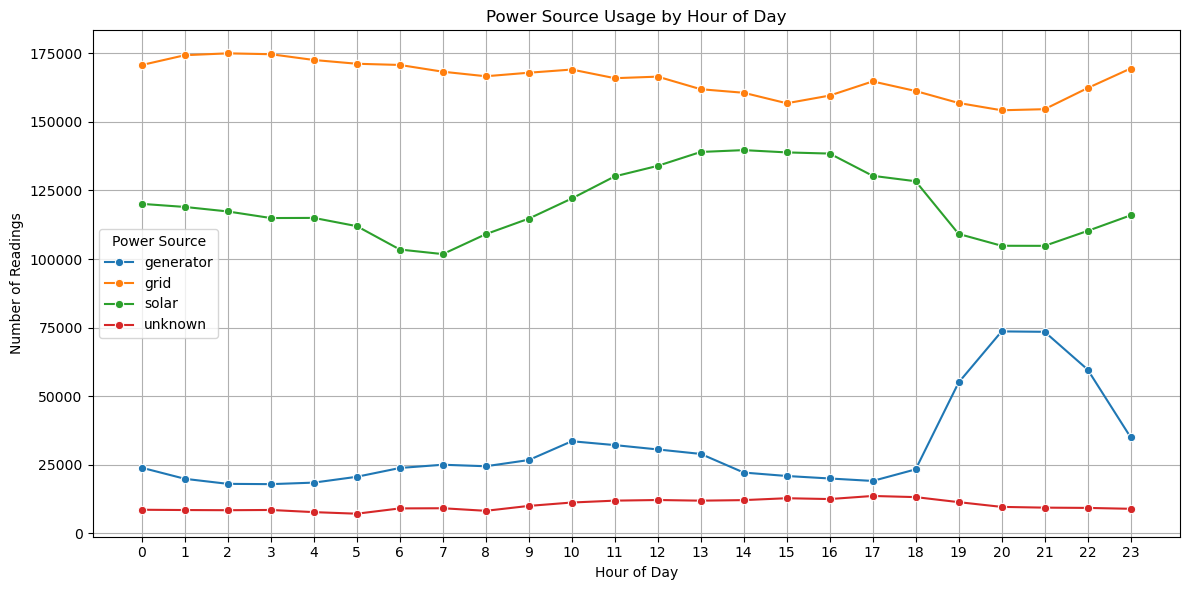

In [65]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_usage, x='hour', y='count', hue='power_source_est', marker='o')
plt.title('Power Source Usage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Readings')
plt.xticks(range(0, 24))  
plt.legend(title='Power Source')
plt.grid(True)
plt.tight_layout()
plt.show()

Some things to look for :

Does solar spike in mid-day hours?

Is grid more common at night?

When does generator usage rise?

#### Power Source by room

In [66]:
def plot_power_source_by_room(hospital_name):
    # Filter for selected hospital
    df_hosp = clean_df[clean_df['hospital'] == hospital_name]
    
    # Group by room and power source
    room_usage = (
        df_hosp.groupby(['room', 'power_source_est'])
        .size()
        .reset_index(name='count')
    )
    
    # Plot
    plt.figure(figsize=(14, 6))
    sns.barplot(data=room_usage, x='room', y='count', hue='power_source_est')
    plt.title(f'Power Source Usage per Room - {hospital_name.title()} Hospital')
    plt.xlabel('Room')
    plt.ylabel('Number of Readings')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Power Source')
    plt.tight_layout()
    plt.show()

In [63]:
hospitals = clean_df["hospital"].unique()
hospitals


array(['hastings', 'magburaka', 'kabala', 'ola_during',
       'princess_christian', 'masanga', 'kambia', 'makeni',
       'king_harman_road', 'wilberforce', 'bonthe', 'connaught'],
      dtype=object)

--- HASTINGS ---


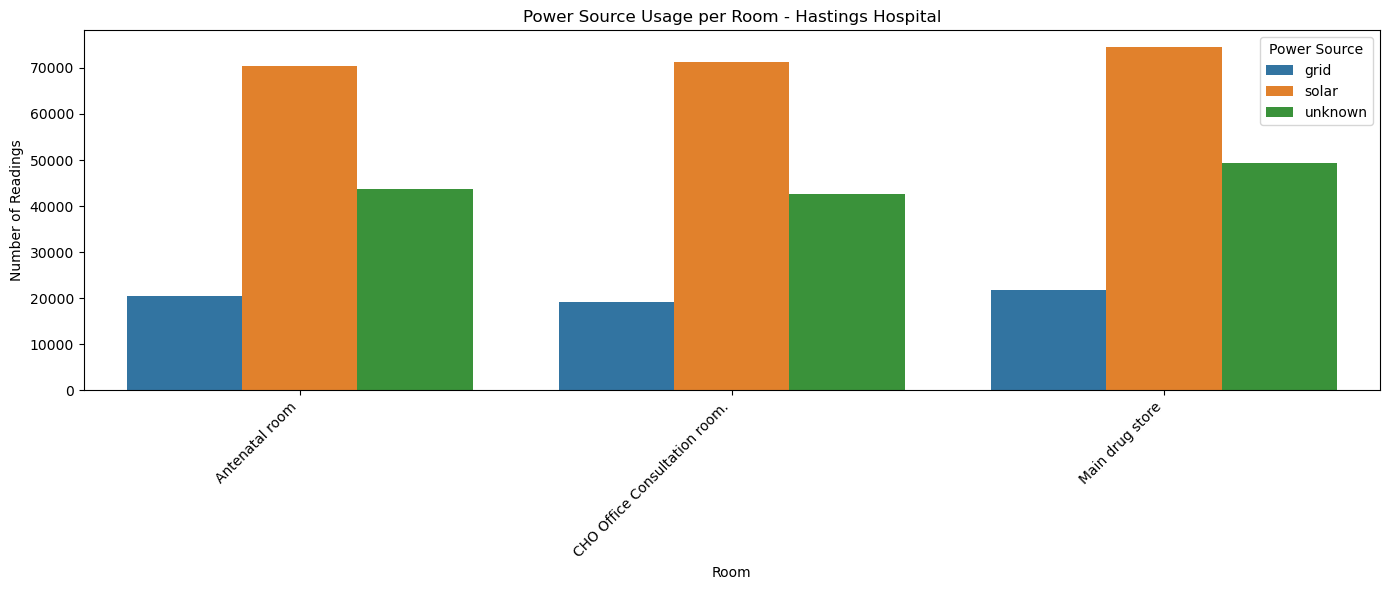

--- MAGBURAKA ---


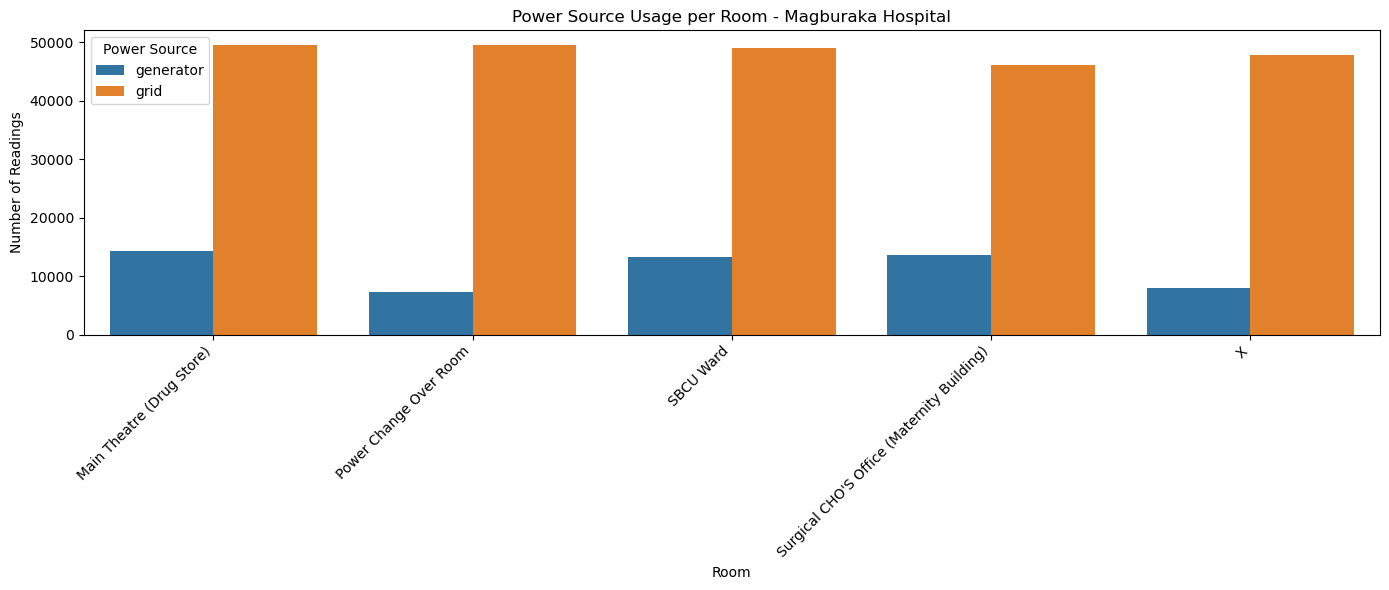

--- KABALA ---


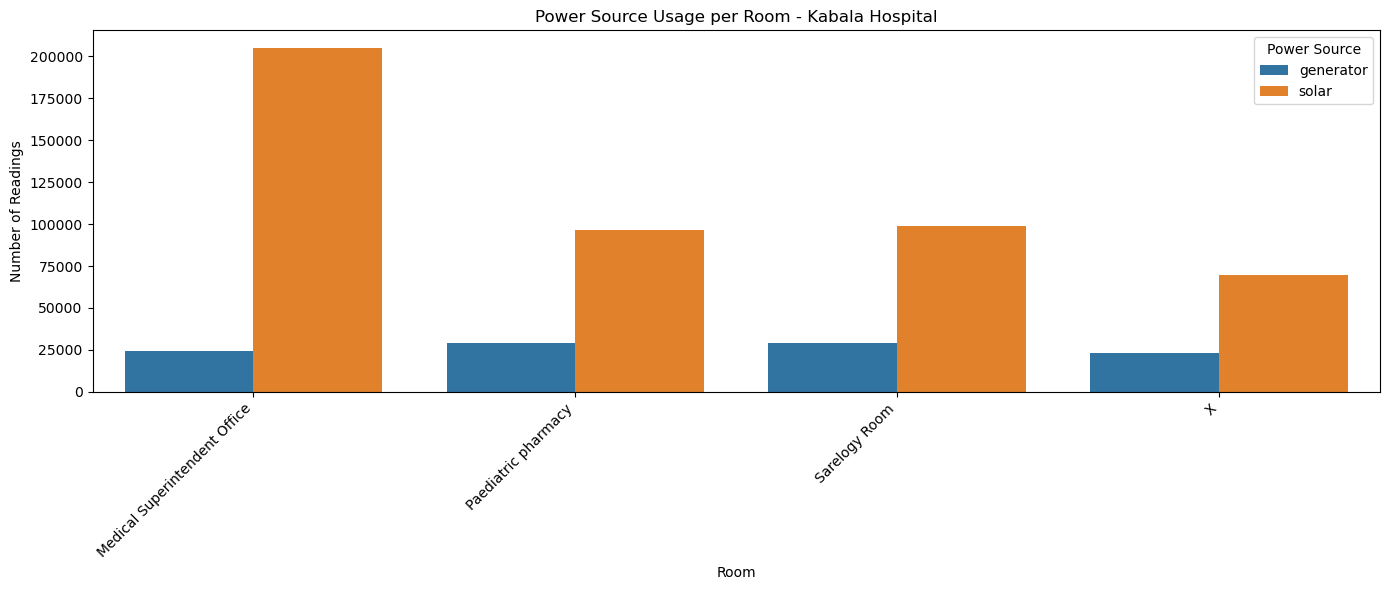

--- OLA_DURING ---


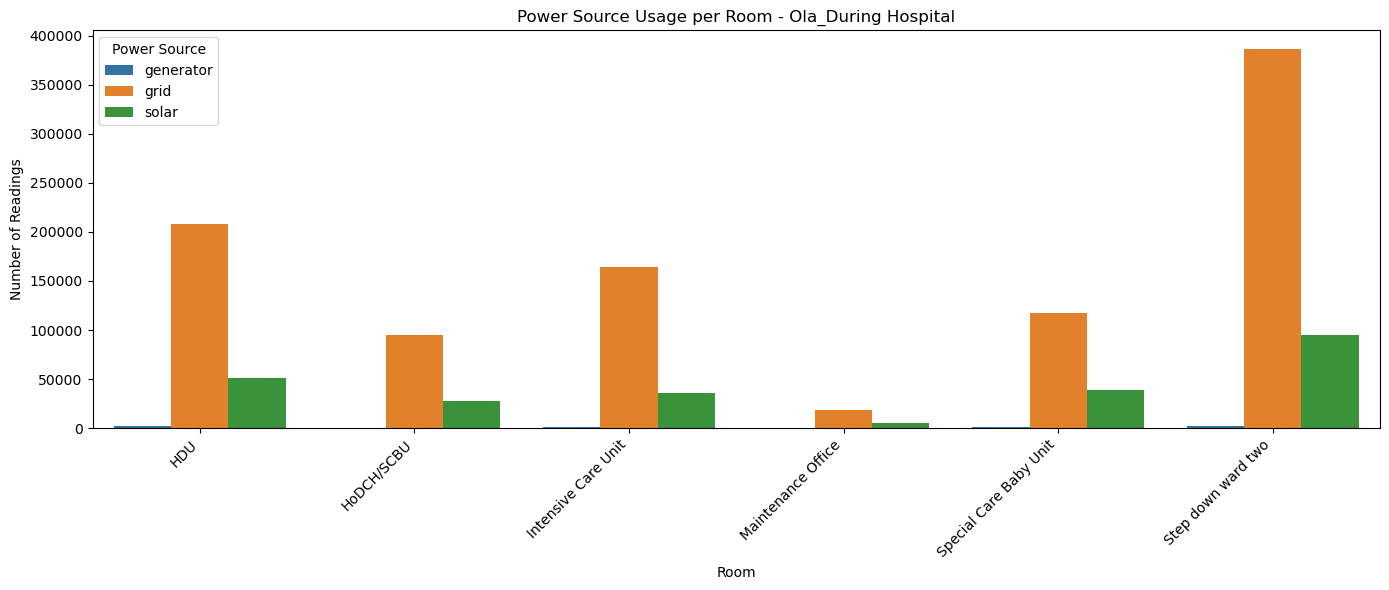

--- PRINCESS_CHRISTIAN ---


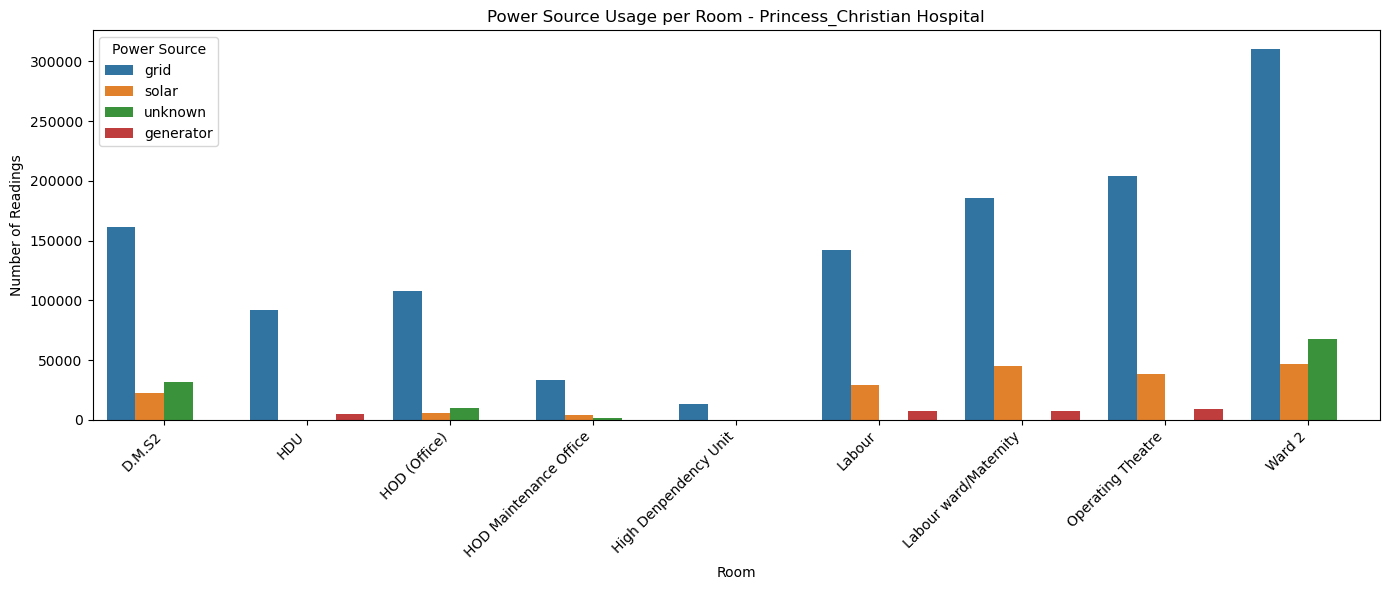

--- MASANGA ---


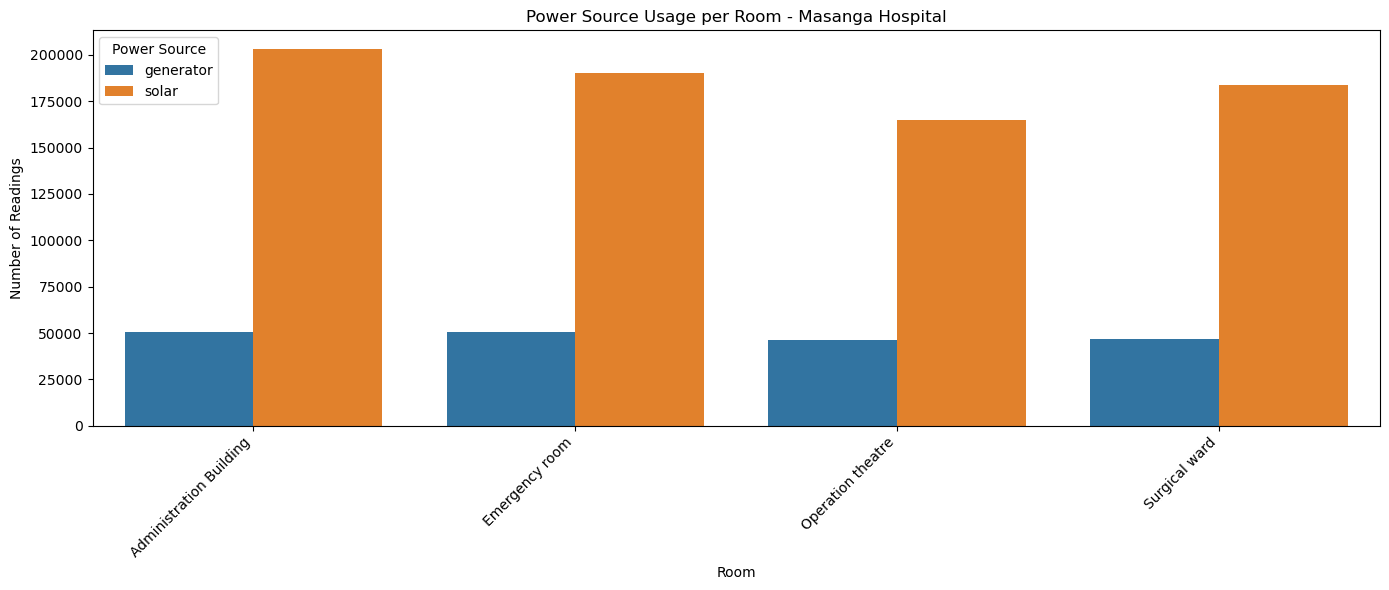

--- KAMBIA ---


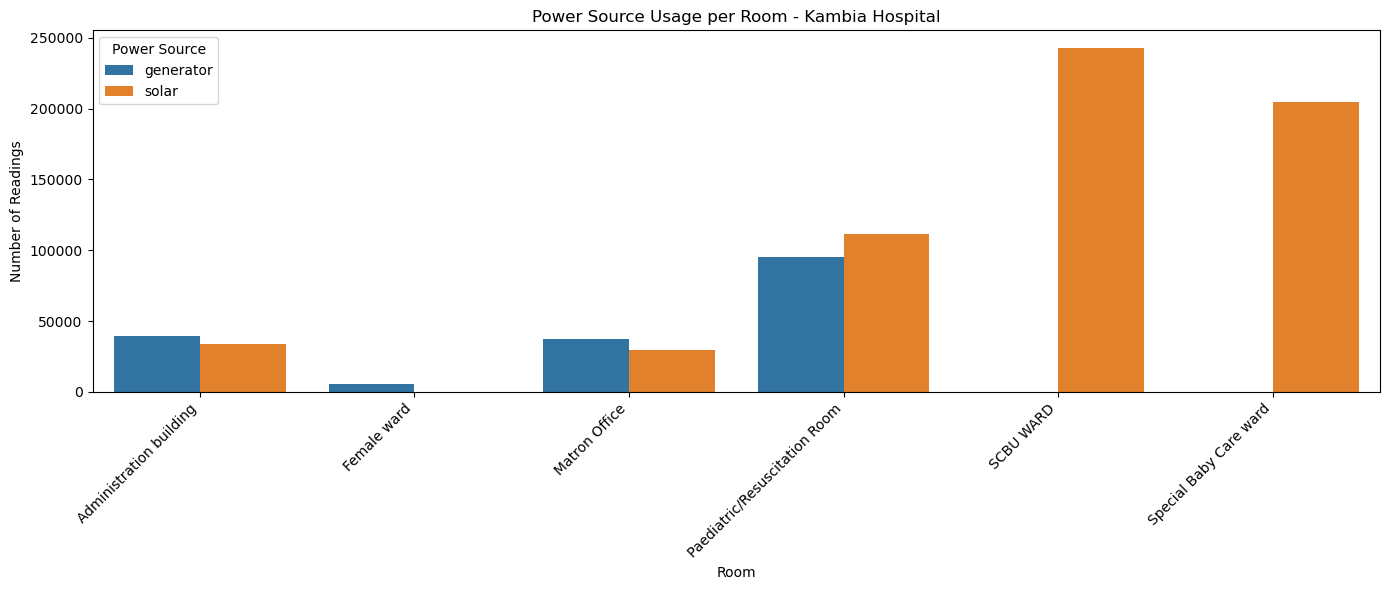

--- MAKENI ---


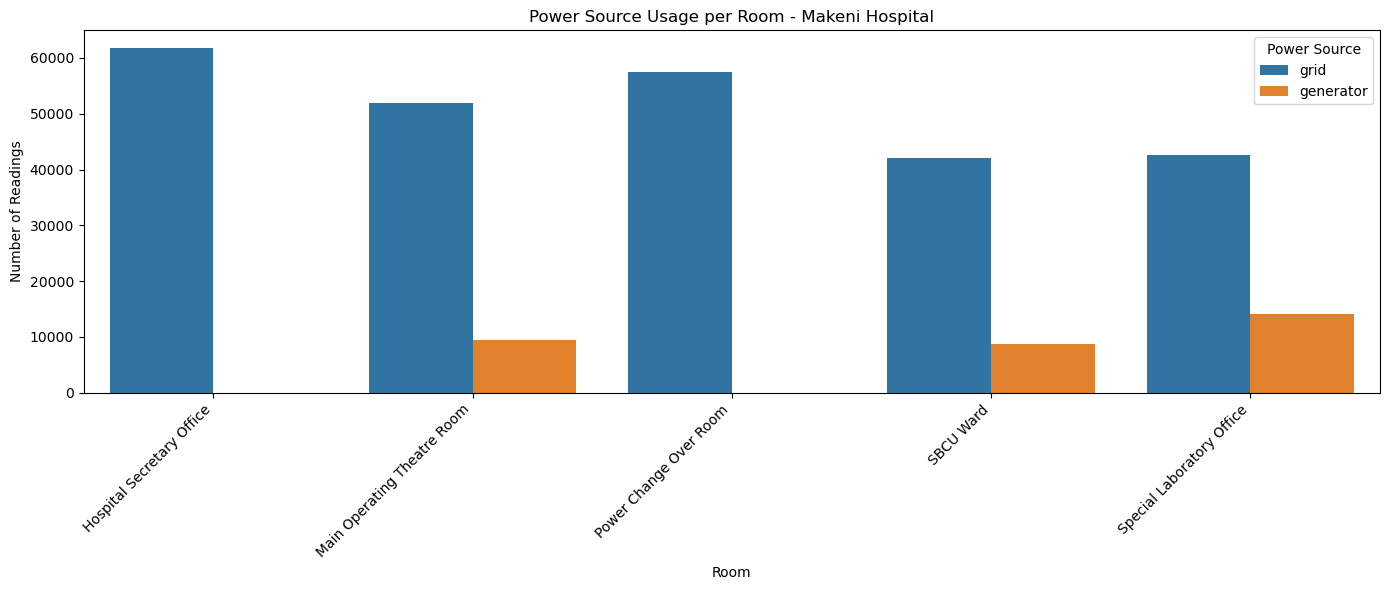

--- KING_HARMAN_ROAD ---


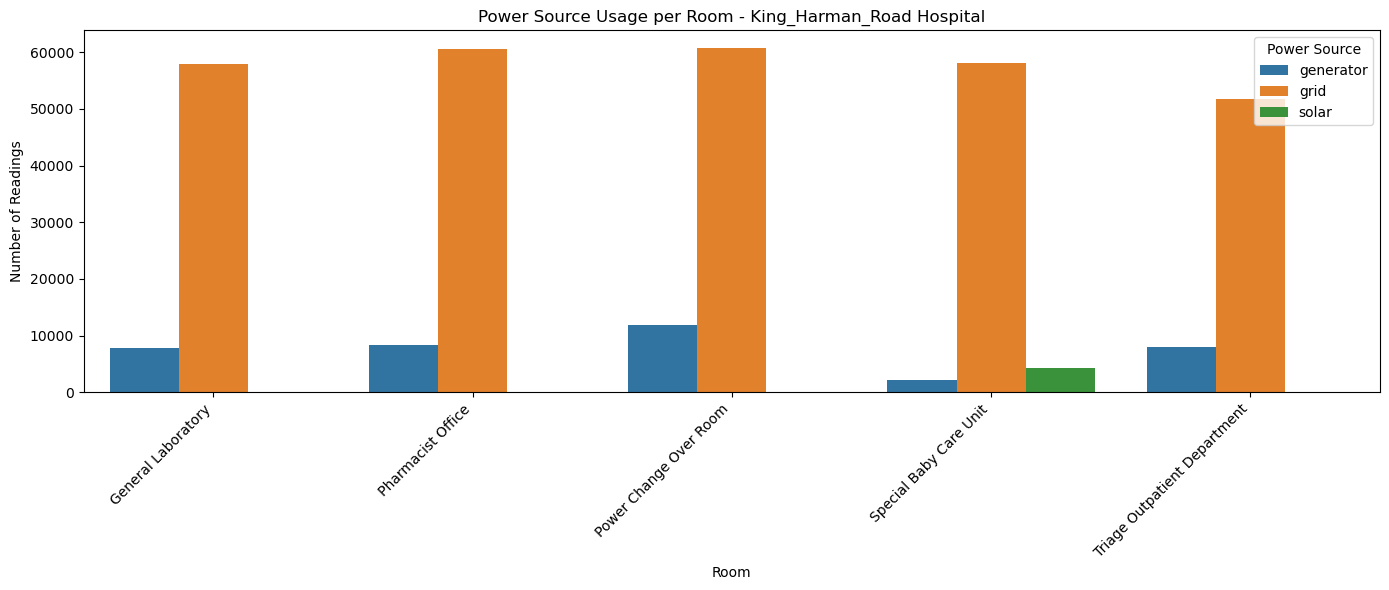

--- WILBERFORCE ---


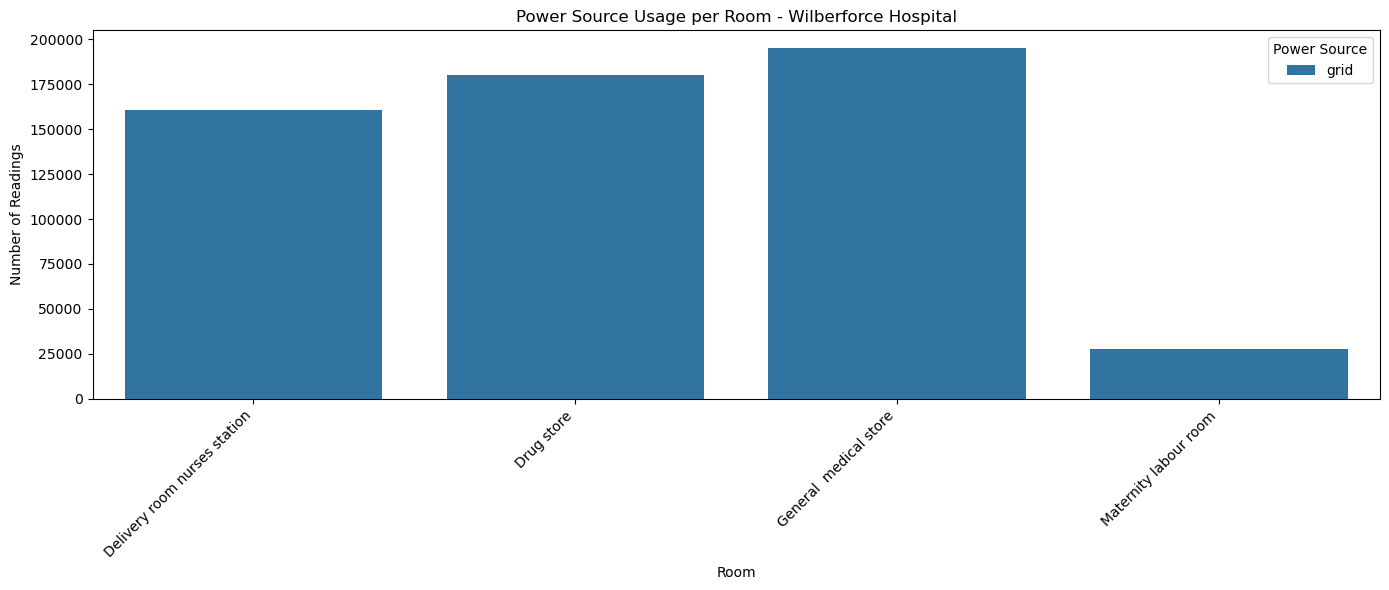

--- BONTHE ---


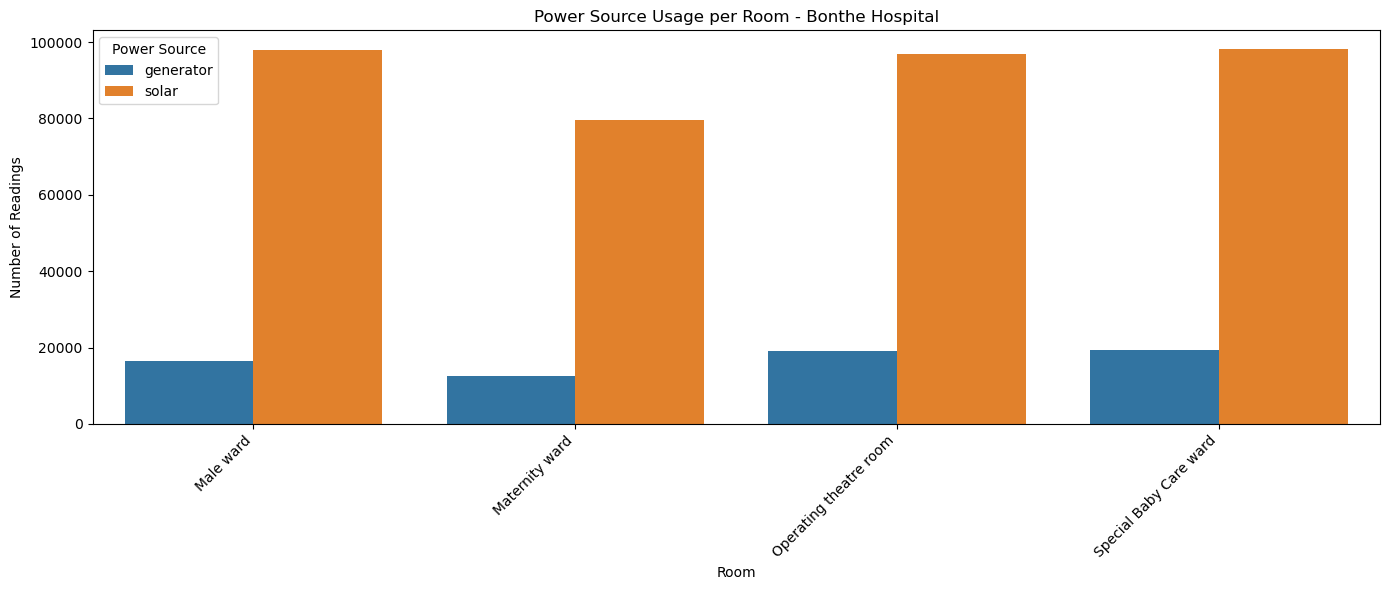

--- CONNAUGHT ---


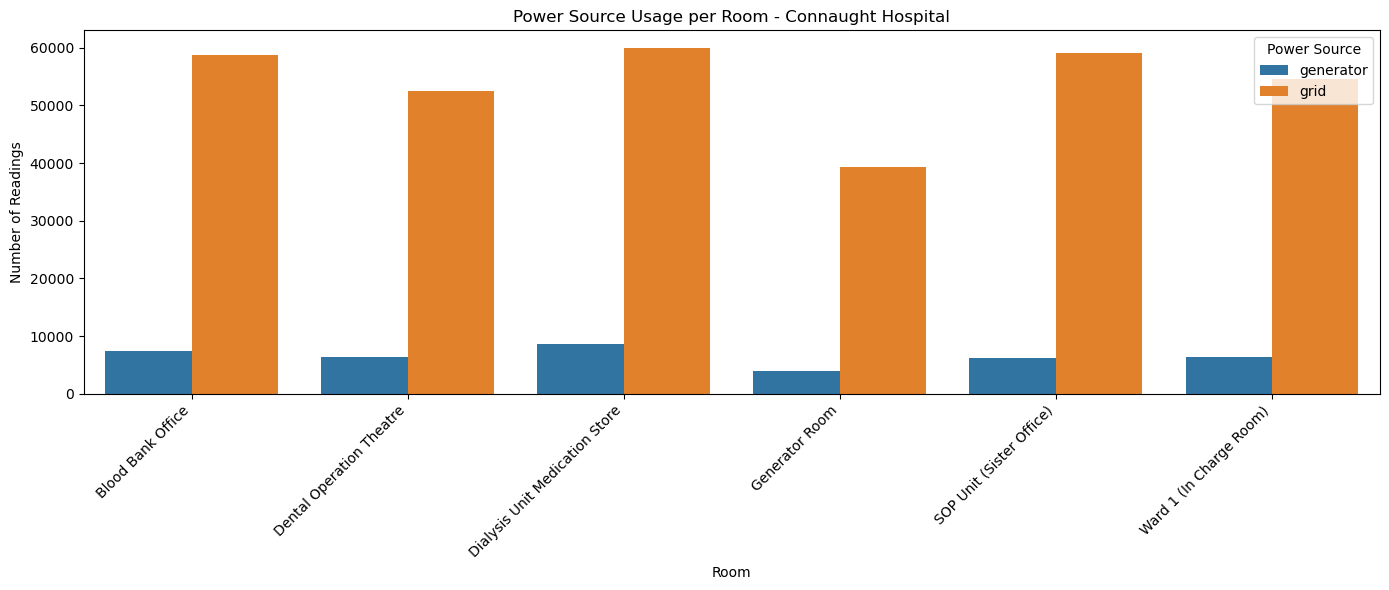

In [64]:
for hosp in hospitals:
    print(f"--- {hosp.upper()} ---")
    plot_power_source_by_room(hospital_name=hosp)

- Which rooms rely most on a particular power source?	
- Do critical rooms (e.g., theatres, ICUs) use backup power (solar/generator) more?
- Are there rooms that rely only on one power source?	

In [67]:
def plot_rolling_usage(source, hospital=None, window_size=30):
    """
    Plots the rolling average time series of power source usage.
    
    Parameters:
    - source: str, e.g., 'solar', 'grid', 'generator'
    - hospital: str or None — filter by hospital if provided
    - window_size: int — size of the rolling window (default 30 = ~1 hour)
    """
    
    # Filter by power source
    df_filtered = clean_df[clean_df['power_source_est'] == source]
    
    # Optional: filter by hospital
    if hospital:
        df_filtered = df_filtered[df_filtered['hospital'] == hospital]
    
    # Group by time
    usage = df_filtered.groupby('time').size().reset_index(name='count')
    
    # Rolling average
    usage['rolling_avg'] = usage['count'].rolling(window=window_size, center=True).mean()
    
    # Plot
    plt.figure(figsize=(15, 6))
    plt.plot(usage['time'], usage['count'], alpha=0.3, label='Raw Count')
    plt.plot(usage['time'], usage['rolling_avg'], color='orange', label=f'Rolling Avg ({window_size * 2} mins)')
    
    title = f"{source.title()} Usage Over Time"
    if hospital:
        title += f" - {hospital.title()}"
    plt.title(title)
    
    plt.xlabel('Time')
    plt.ylabel('Number of Readings')
    plt.legend()
    plt.tight_layout()
    plt.show()


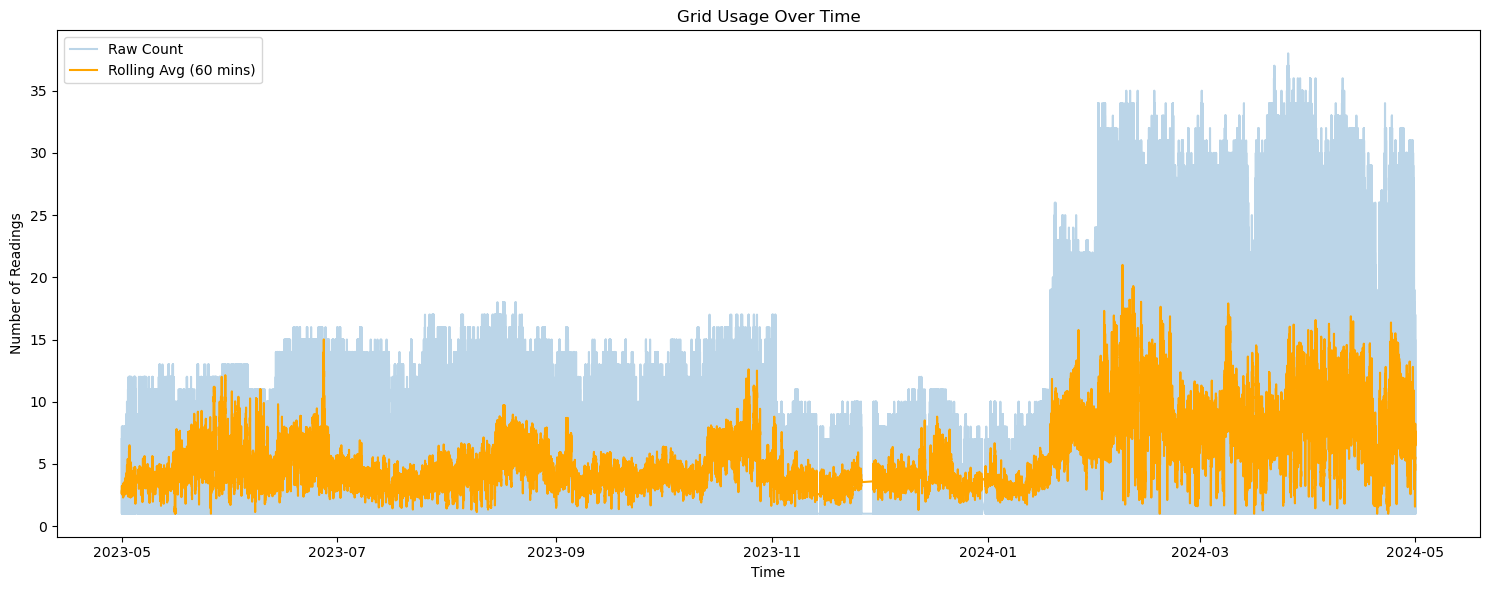

In [66]:
# Solar usage across all hospitals
plot_rolling_usage('grid')

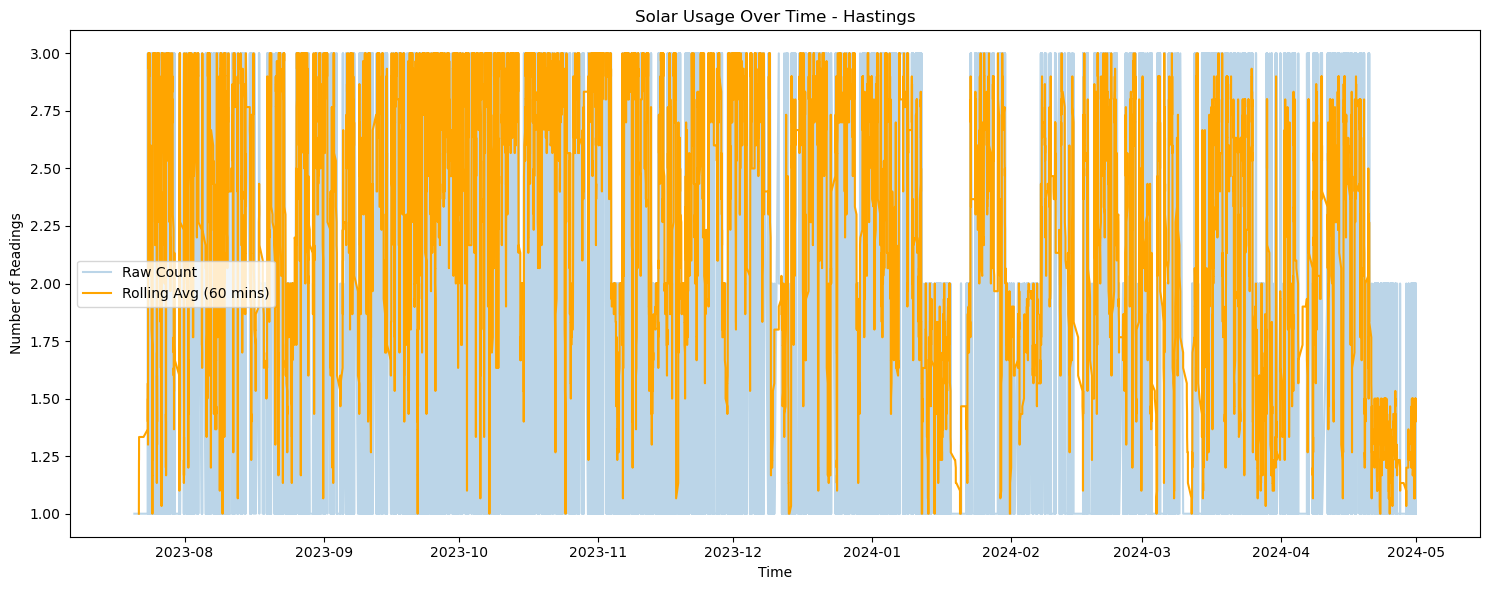

In [67]:
# Generator usage at a specific hospital
plot_rolling_usage(source='solar', hospital='hastings')

Analyze power source usage over time

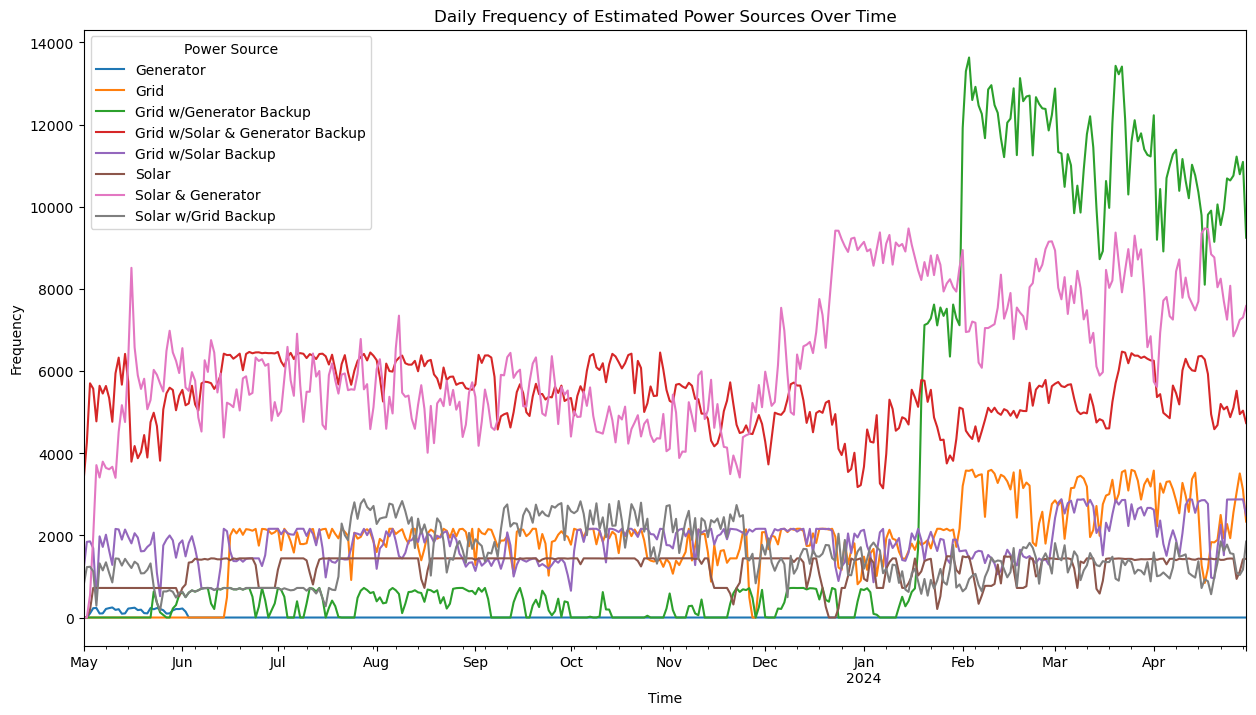

In [68]:
daily_power_source_frequency = clean_df.groupby(pd.Grouper(key='time', freq='D'))['power_source'].value_counts().unstack(fill_value=0)

plt.figure(figsize=(15, 8))
daily_power_source_frequency.plot(kind='line', ax=plt.gca())
plt.title('Daily Frequency of Estimated Power Sources Over Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.legend(title='Power Source')
plt.show()

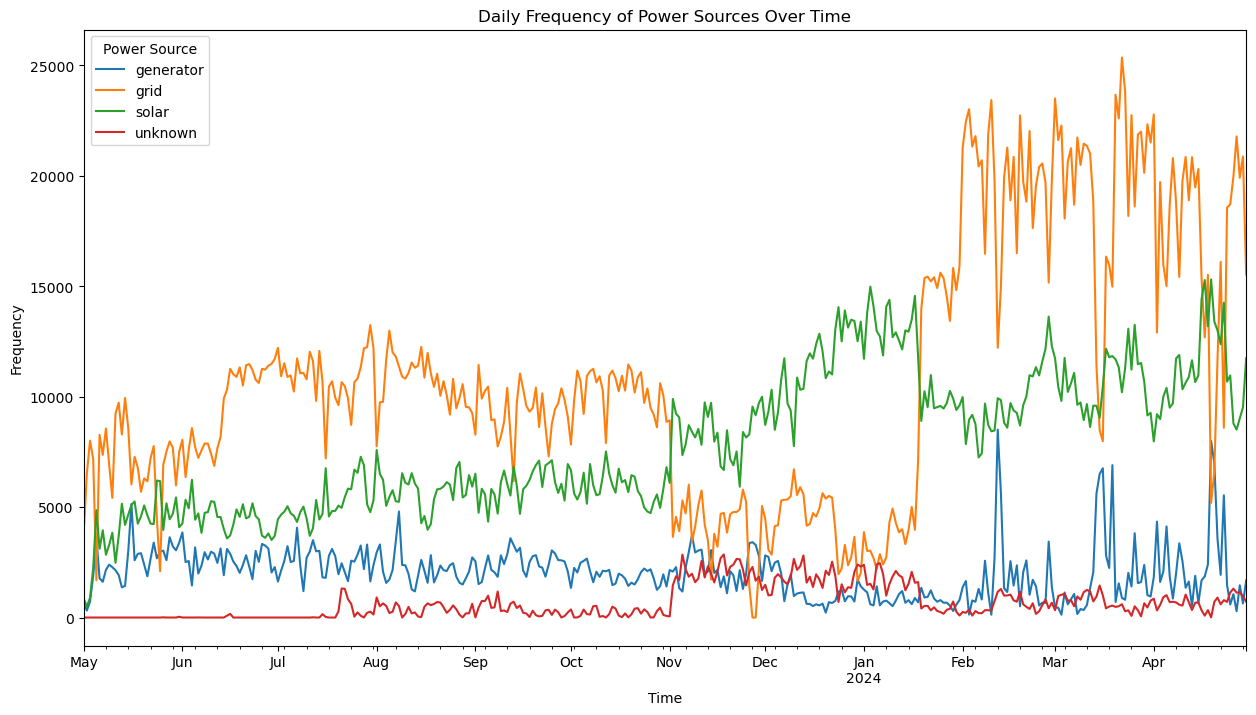

In [69]:
daily_power_source_frequency = clean_df.groupby(pd.Grouper(key='time', freq='D'))['power_source_est'].value_counts().unstack(fill_value=0)

plt.figure(figsize=(15, 8))
daily_power_source_frequency.plot(kind='line', ax=plt.gca())
plt.title('Daily Frequency of Power Sources Over Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.legend(title='Power Source')
plt.show()

#### Voltage and Frequency distributions

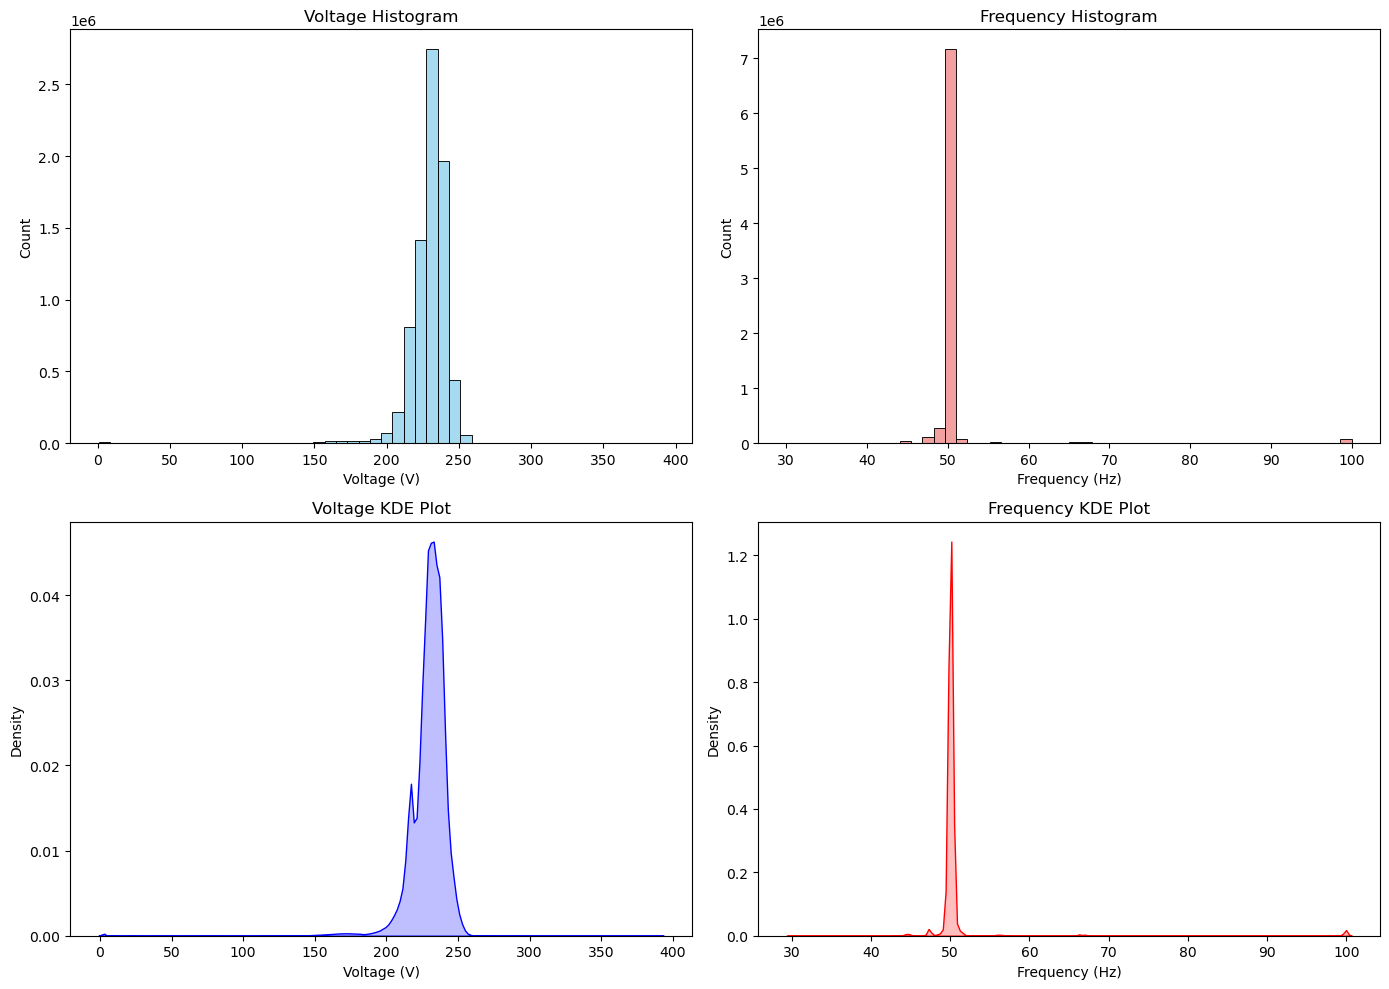

In [70]:

plt.figure(figsize=(14, 10))

# 1. Voltage Histogram
plt.subplot(2, 2, 1)
sns.histplot(clean_df['voltage'], bins=50, kde=False, color='skyblue')
plt.title('Voltage Histogram')
plt.xlabel('Voltage (V)')

# 2. Frequency Histogram
plt.subplot(2, 2, 2)
sns.histplot(clean_df['frequency'], bins=50, kde=False, color='lightcoral')
plt.title('Frequency Histogram')
plt.xlabel('Frequency (Hz)')

# 3. Voltage KDE
plt.subplot(2, 2, 3)
sns.kdeplot(clean_df['voltage'], fill=True, color='blue')
plt.title('Voltage KDE Plot')
plt.xlabel('Voltage (V)')

# 4. Frequency KDE
plt.subplot(2, 2, 4)
sns.kdeplot(clean_df['frequency'], fill=True, color='red')
plt.title('Frequency KDE Plot')
plt.xlabel('Frequency (Hz)')

plt.tight_layout()
plt.show()



In [69]:
outliers_freq = clean_df[clean_df['frequency'] > 67]
outliers_freq.sample(20)


,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date
130668,2023-09-12 12:20:03,BBFDA35A,Main drug store,hastings,215.700141,99.930049,Solar w/Grid Backup,unknown,12,Tuesday,2023-09-12
1722290,2023-08-21 04:20:03,CA7A6C34,Antenatal room,hastings,217.114569,99.940036,Solar w/Grid Backup,solar,4,Monday,2023-08-21
1715296,2023-12-03 11:36:03,CA7A6C34,Antenatal room,hastings,217.821782,99.830289,Solar w/Grid Backup,unknown,11,Sunday,2023-12-03
5558304,2024-04-25 20:28:12,293BAF37,CHO Office Consultation room.,hastings,214.285714,99.930049,Solar w/Grid Backup,unknown,20,Thursday,2024-04-25
5545460,2024-03-17 12:34:03,293BAF37,CHO Office Consultation room.,hastings,210.749646,99.830289,Solar w/Grid Backup,unknown,12,Sunday,2024-03-17
86612,2023-08-21 09:04:03,BBFDA35A,Main drug store,hastings,216.407355,67.033114,Solar w/Grid Backup,unknown,9,Monday,2023-08-21
5580053,2023-12-25 16:12:03,293BAF37,CHO Office Consultation room.,hastings,217.821782,99.850225,Solar w/Grid Backup,unknown,16,Monday,2023-12-25
47332,2023-10-01 16:16:03,BBFDA35A,Main drug store,hastings,220.650636,99.960016,Solar w/Grid Backup,unknown,16,Sunday,2023-10-01
1793187,2023-08-03 07:40:03,CA7A6C34,Antenatal room,hastings,216.407355,99.910081,Solar w/Grid Backup,unknown,7,Thursday,2023-08-03
1646235,2024-04-20 16:08:13,CA7A6C34,Antenatal room,hastings,212.871287,99.980004,Solar w/Grid Backup,unknown,16,Saturday,2024-04-20


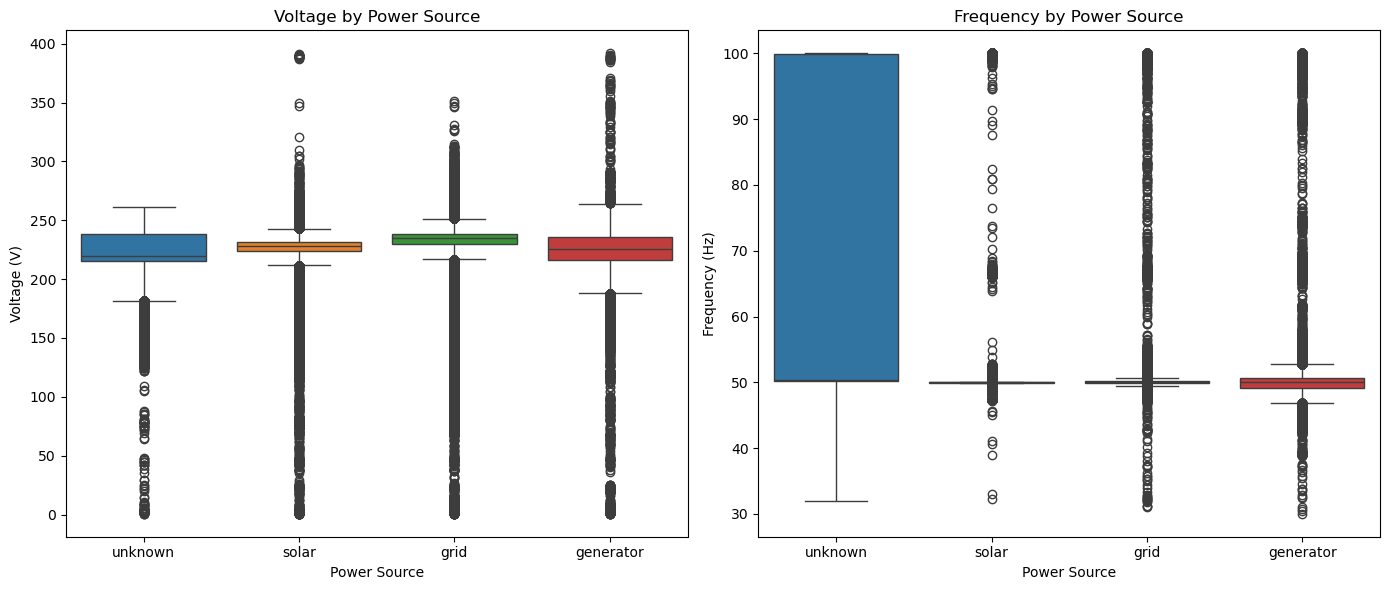

In [72]:
plt.figure(figsize=(14, 6))

# Voltage
plt.subplot(1, 2, 1)
sns.boxplot(data=clean_df, x='power_source_est', y='voltage',hue='power_source_est')
plt.title('Voltage by Power Source')
plt.xlabel('Power Source')
plt.ylabel('Voltage (V)')

# Frequency
plt.subplot(1, 2, 2)
sns.boxplot(data=clean_df, x='power_source_est', y='frequency',hue='power_source_est')
plt.title('Frequency by Power Source')
plt.xlabel('Power Source')
plt.ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()


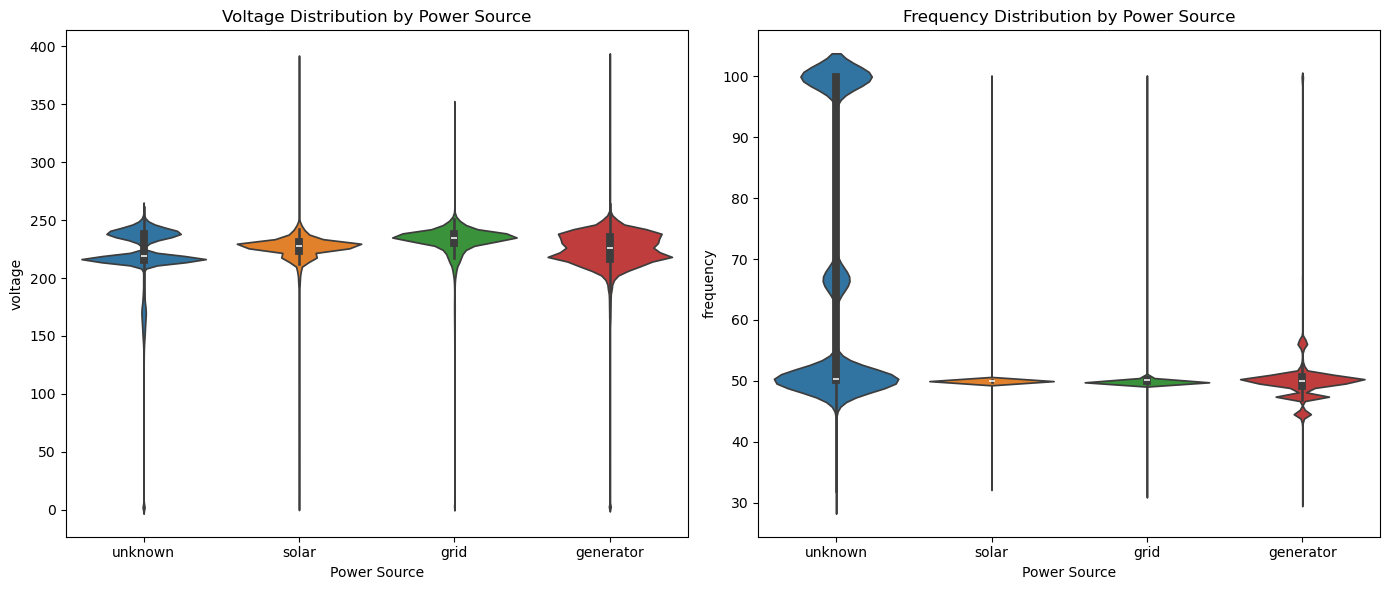

In [73]:
plt.figure(figsize=(14, 6))

# Voltage
plt.subplot(1, 2, 1)
sns.violinplot(data=clean_df, x='power_source_est', y='voltage', hue='power_source_est')
plt.title('Voltage Distribution by Power Source')
plt.xlabel('Power Source')

# Frequency
plt.subplot(1, 2, 2)
sns.violinplot(data=clean_df, x='power_source_est', y='frequency', hue='power_source_est')
plt.title('Frequency Distribution by Power Source')
plt.xlabel('Power Source')

plt.tight_layout()
plt.show()


# Correlations

#### Power Source Usage Heatmap (by Day + Hour)

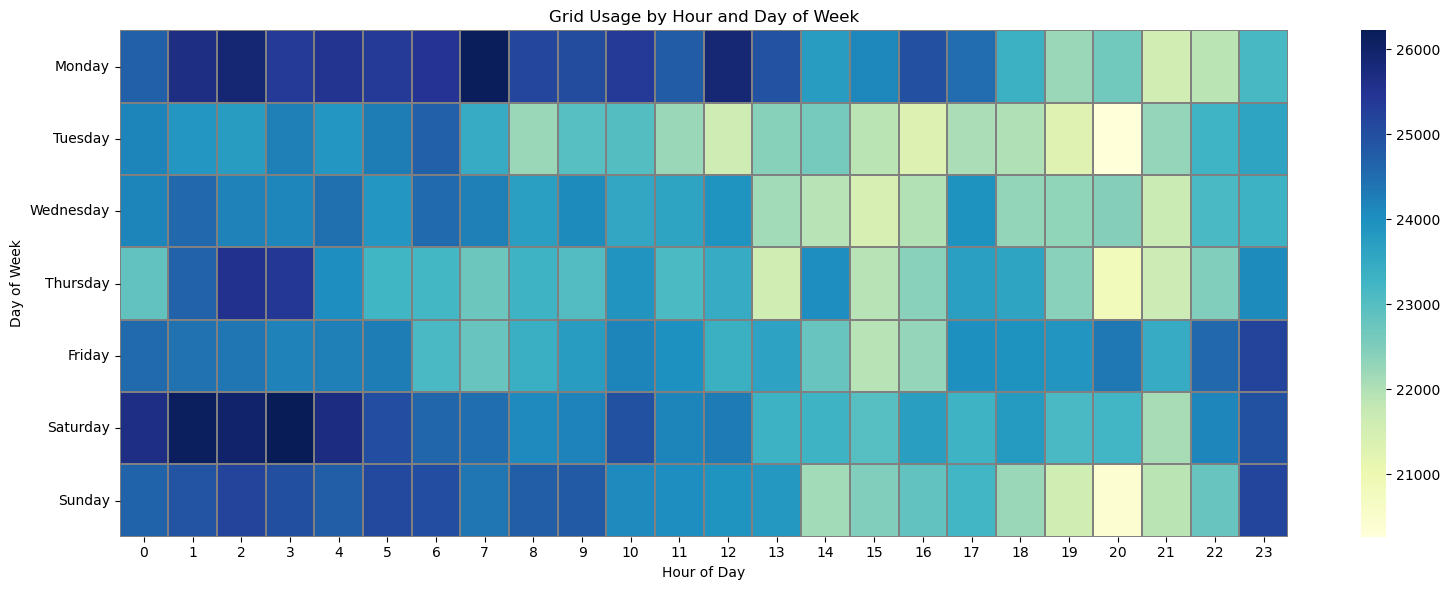

In [70]:
# Choose a power source- you can change the source to view the hit map
source = 'grid'  # Options: 'solar', 'grid', 'generator', 'unknown'

# Filter dataset
df_source = clean_df[clean_df['power_source_est'] == source]

# Group by day of week and hour
usage_matrix = (
    df_source.groupby(['day_of_week', 'hour'])
    .size()
    .reset_index(name='count')
)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
usage_matrix['day_of_week'] = pd.Categorical(usage_matrix['day_of_week'], categories=day_order, ordered=True)

heatmap_data = usage_matrix.pivot(index='day_of_week', columns='hour', values='count').fillna(0)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.2, linecolor='gray')
plt.title(f'{source.title()} Usage by Hour and Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()



Notes:

When solar is most active (likely mid-day)

If generator use spikes at night or weekends

Grid outages or load shedding patterns

### Cross-tab: power source usage by hospital


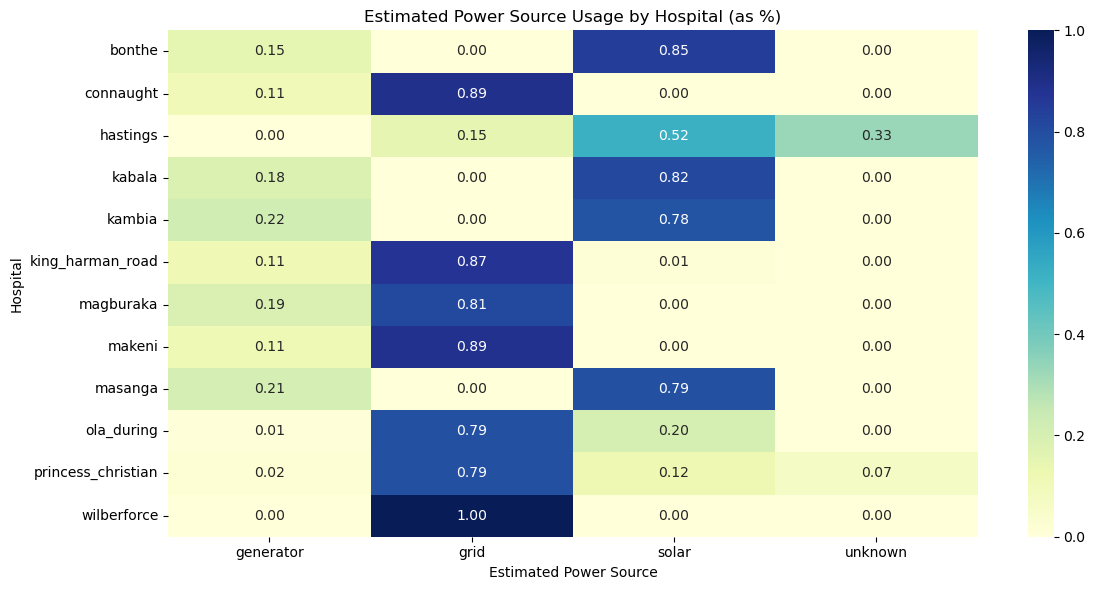

In [75]:
# Cross-tab: power source usage by hospital
hospital_power = pd.crosstab(clean_df['hospital'], clean_df['power_source_est'])

# Optional: Normalize to see percentages
hospital_power_percent = hospital_power.div(hospital_power.sum(axis=1), axis=0)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(hospital_power_percent, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Estimated Power Source Usage by Hospital (as %)")
plt.ylabel("Hospital")
plt.xlabel("Estimated Power Source")
plt.tight_layout()
plt.show()

Relationship between power source and estimated power source

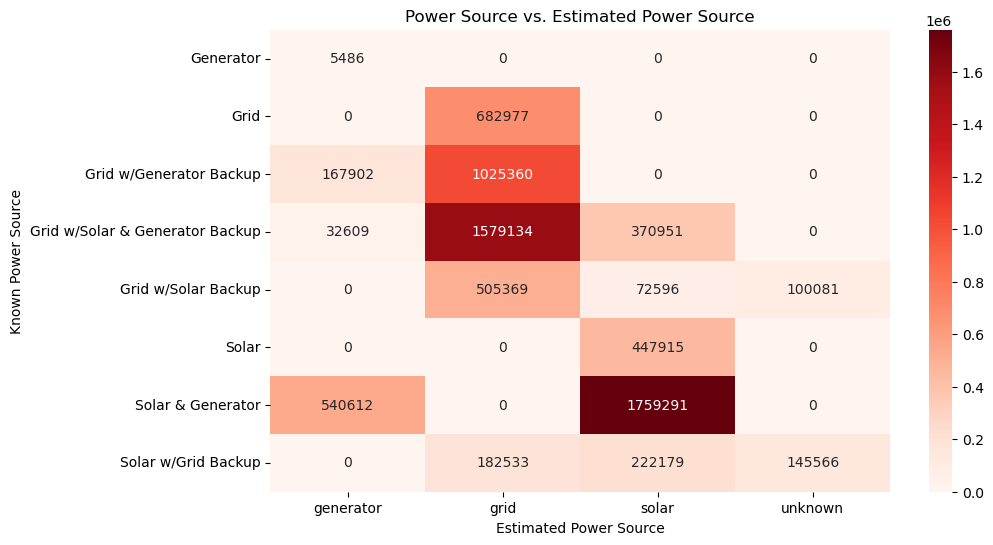

In [76]:
# Cross-tabulation of power_source vs. estimated_power_source
cross_tab = pd.crosstab(clean_df['power_source'], clean_df['power_source_est'])

# Visualize cross-tabulation
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Reds')
plt.title('Power Source vs. Estimated Power Source')
plt.xlabel('Estimated Power Source')
plt.ylabel('Known Power Source')
plt.show()

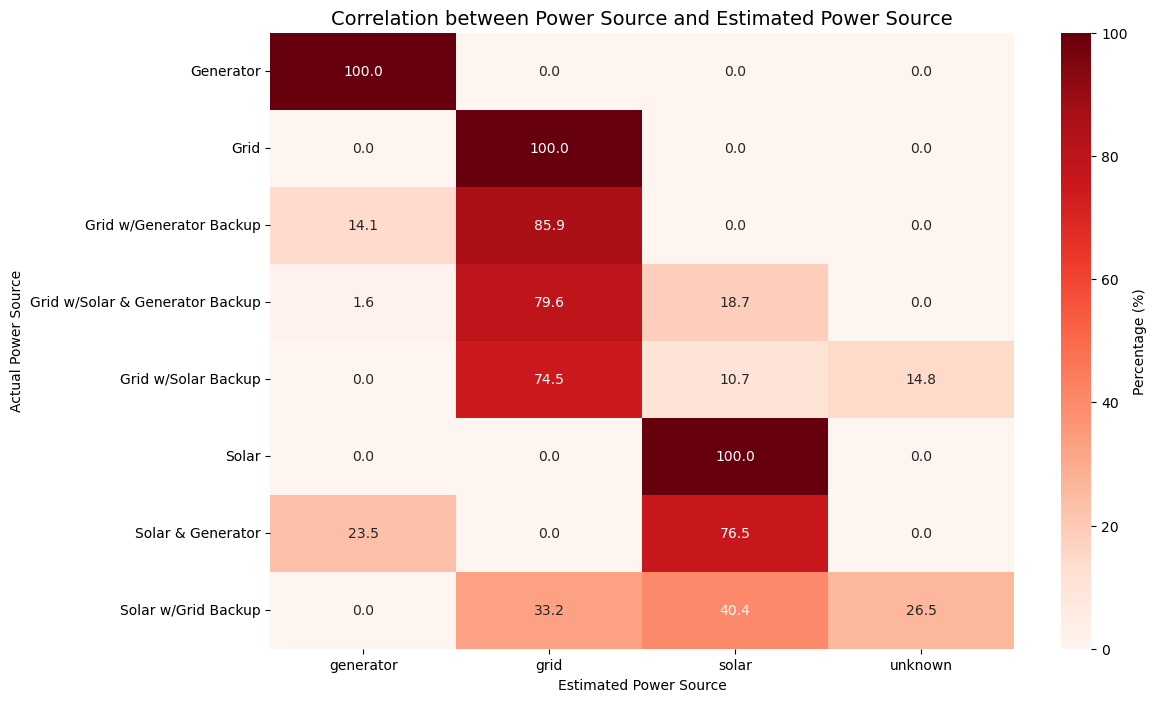

In [77]:
corr_table = pd.crosstab(clean_df['power_source'], clean_df['power_source_est'], normalize='index') * 100

plt.figure(figsize=(12, 8))
sns.heatmap(corr_table, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Percentage (%)'})
plt.title("Correlation between Power Source and Estimated Power Source", fontsize=14)
plt.xlabel("Estimated Power Source")
plt.ylabel("Actual Power Source")
plt.show()

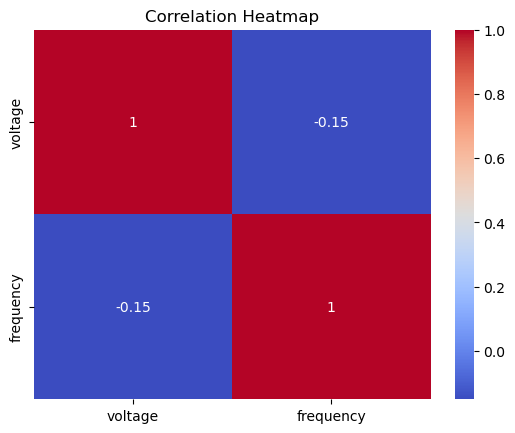

In [71]:
# Heatmap for Correlation
sns.heatmap(clean_df[['voltage', 'frequency']].corr(), annot=True, cmap='coolwarm' )
plt.title('Correlation Heatmap')
plt.show()

## Machine Learning 

In this section we are going to explore various ML models based on existing features and new features then compare the performance. We Use supervised machine learning algorithms to predict the `power_source_est` based on the `voltage` and `frequency` features. Train and evaluate various models, then select the best-performing one.

In [72]:
clean_df.head(5)

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date
0,2023-07-22 20:42:03,BBFDA35A,Main drug store,hastings,221.357850,99.940036,Solar w/Grid Backup,unknown,20,Saturday,2023-07-22
1,2023-07-23 06:58:03,BBFDA35A,Main drug store,hastings,221.357850,99.790440,Solar w/Grid Backup,unknown,6,Sunday,2023-07-23
2,2023-07-23 13:46:03,BBFDA35A,Main drug store,hastings,221.357850,99.920064,Solar w/Grid Backup,unknown,13,Sunday,2023-07-23
3,2023-07-23 23:34:03,BBFDA35A,Main drug store,hastings,217.114569,49.957536,Solar w/Grid Backup,solar,23,Sunday,2023-07-23
4,2023-07-24 00:18:03,BBFDA35A,Main drug store,hastings,219.943423,50.017506,Solar w/Grid Backup,solar,0,Monday,2023-07-24


In [73]:
X= clean_df[['voltage', 'frequency']]
y= clean_df['power_source_est']

Label Encoding the data

In [74]:
from sklearn.preprocessing import LabelEncoder
L = LabelEncoder()
L.fit(y)
y_encoded = L.transform(y)

print("Classes:", L.classes_)
print("Encoded Labels:", y_encoded[:5])

Classes: ['generator' 'grid' 'solar' 'unknown']
Encoded Labels: [3 3 3 2 2]


Split the data into training and test data. This is the first step of ML training , we are going to train and evaluate the models without adding new features then compare the model performance after adding new features

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

### Supervised Machine Learning models -Classification

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [4]:
#Initialize models
Regressor=LogisticRegression()
DTC=DecisionTreeClassifier()
RFC=RandomForestClassifier()
SVC_model=SVC()
KNN=KNeighborsClassifier()

#### 1. Logistic Regression

In [ ]:
#Fit the models
Regressor.fit(X_train,y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [107]:
y_pred_regressor = Regressor.predict(X_test)


In [108]:
testdf = pd.DataFrame([[225.3939, 49.6179]])
	
testdf.columns = X.columns
predicted_class = Regressor.predict(testdf)
predicted_label = L.inverse_transform(predicted_class)
print("Predicted Power Source:", predicted_label[0])

Predicted Power Source: grid


In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Calculate and print metrics for Logistic Regression
print("--- Logistic Regression Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_regressor))
print("Precision:", precision_score(y_test, y_pred_regressor, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_regressor, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_regressor, average='weighted', zero_division=0))

--- Logistic Regression Metrics ---
Accuracy: 0.5535863805733388
Precision: 0.5102137046414777
Recall: 0.5535863805733388
F1-score: 0.49174523081807214


#### 2. Decision Tree Classifier

In [93]:
DTC.fit(X_train,y_train)

DecisionTreeClassifier()

In [106]:
testdf = pd.DataFrame([[220.0000, 99.6179]])
testdf.columns = X.columns
predicted_class = DTC.predict(testdf)
predicted_label = L.inverse_transform(predicted_class)
print("Predicted Power Source:", predicted_label[0])

Predicted Power Source: generator


In [110]:
y_pred_dtc = DTC.predict(X_test)

In [111]:
print("\n--- Decision Tree Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dtc))
print("Precision:", precision_score(y_test,y_pred_dtc, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dtc, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_dtc, average='weighted', zero_division=0))


--- Decision Tree Metrics ---
Accuracy: 0.8264748777670997
Precision: 0.8300579332571243
Recall: 0.8264748777670997
F1-score: 0.8224884168067575


#### 3. Random Frorest Classifier

In [112]:
RFC.fit(X_train,y_train)

RandomForestClassifier()

In [114]:
testdf = pd.DataFrame([[225.3939, 99.6179]])
testdf.columns = X.columns
predicted_class = DTC.predict(testdf)
predicted_label = L.inverse_transform(predicted_class)
print("Predicted Power Source:", predicted_label[0])

Predicted Power Source: generator


In [115]:
y_pred_rfc = RFC.predict(X_test)


In [116]:
print("\n--- Random Forest Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rfc))
print("Precision:", precision_score(y_test, y_pred_rfc, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rfc, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_rfc, average='weighted', zero_division=0))


--- Random Forest Metrics ---
Accuracy: 0.826656624873335
Precision: 0.8304004308598989
Recall: 0.826656624873335
F1-score: 0.8226173344270912


#### 4. SVC

In [ ]:
SVC_model.fit(X_train,y_train)

In [ ]:
testdf = pd.DataFrame([[225.3939, 49.6179]])
testdf.columns = X.columns
predicted_class = SVC_model.predict(testdf)
predicted_label = L.inverse_transform(predicted_class)
print("Predicted Power Source:", predicted_label[0])

In [ ]:
y_pred_svc = SVC_model.predict(X_test)


In [ ]:
print("\n--- Support Vector Machine Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Precision:", precision_score(y_test, y_pred_svc, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_svc, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_svc, average='weighted', zero_division=0))

#### 5. K-Nearest Neighbours

In [76]:
KNN.fit(X_train,y_train)

KNeighborsClassifier()

In [77]:
testdf = pd.DataFrame([[225.3939, 49.6179]])
testdf.columns = X.columns
predicted_class = KNN.predict(testdf)
predicted_label = L.inverse_transform(predicted_class)
print("Predicted Power Source:", predicted_label[0])

Predicted Power Source: grid


In [78]:
y_pred_knn = KNN.predict(X_test)


In [ ]:
print("\n--- K-Nearest Neighbors Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_knn, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_knn, average='weighted', zero_division=0))

## **Feature Engineering**

- Frequency Deviation: From the median frequency of the electrically closest grid-only room (threshold: ≤0.11Hz for grid).
- Frequency Spread/Variability: Mean Absolute Deviation (MAD) in a 15-minute sliding window (≤0.1 for solar).
- Room Power Source Label: Ground-truth configurations 


#### 1. Frequency deviation

In [81]:
mean_value = clean_df['frequency'].mean()
clean_df['freq_deviation']= abs(clean_df['frequency'] - mean_value)
clean_df.head()

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date,freq_deviation
0,2023-07-22 20:42:03,BBFDA35A,Main drug store,hastings,221.357850,99.940036,Solar w/Grid Backup,unknown,20,Saturday,2023-07-22,49.303431
1,2023-07-23 06:58:03,BBFDA35A,Main drug store,hastings,221.357850,99.790440,Solar w/Grid Backup,unknown,6,Sunday,2023-07-23,49.153835
2,2023-07-23 13:46:03,BBFDA35A,Main drug store,hastings,221.357850,99.920064,Solar w/Grid Backup,unknown,13,Sunday,2023-07-23,49.283459
3,2023-07-23 23:34:03,BBFDA35A,Main drug store,hastings,217.114569,49.957536,Solar w/Grid Backup,solar,23,Sunday,2023-07-23,0.679069
4,2023-07-24 00:18:03,BBFDA35A,Main drug store,hastings,219.943423,50.017506,Solar w/Grid Backup,solar,0,Monday,2023-07-24,0.619099


In [83]:
newdf = clean_df[['frequency','power_source_est','freq_deviation' ]]
newdf.head(10)

,frequency,power_source_est,freq_deviation
0,99.940036,unknown,49.303431
1,99.790440,unknown,49.153835
2,99.920064,unknown,49.283459
3,49.957536,solar,0.679069
4,50.017506,solar,0.619099
5,50.032521,solar,0.604084
6,49.992501,solar,0.644104
7,49.965024,solar,0.671580
8,50.010002,solar,0.626603
9,50.037528,solar,0.599077


In [88]:
Q1 = clean_df['frequency'].quantile(0.25)
Q3 = clean_df['frequency'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = clean_df[(clean_df['frequency'] < lower_bound) | (clean_df['frequency'] > upper_bound)]

print("Outliers in the frequency column:")
display(outliers)

Outliers in the frequency column:


,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date,freq_deviation
0,2023-07-22 20:42:03,BBFDA35A,Main drug store,hastings,221.357850,99.940036,Solar w/Grid Backup,unknown,20,Saturday,2023-07-22,49.303431
1,2023-07-23 06:58:03,BBFDA35A,Main drug store,hastings,221.357850,99.790440,Solar w/Grid Backup,unknown,6,Sunday,2023-07-23,49.153835
2,2023-07-23 13:46:03,BBFDA35A,Main drug store,hastings,221.357850,99.920064,Solar w/Grid Backup,unknown,13,Sunday,2023-07-23,49.283459
11,2023-07-29 18:26:03,BBFDA35A,Main drug store,hastings,166.902405,49.329124,Solar w/Grid Backup,grid,18,Saturday,2023-07-29,1.307481
12,2023-07-29 21:10:03,BBFDA35A,Main drug store,hastings,166.195191,49.531923,Solar w/Grid Backup,grid,21,Saturday,2023-07-29,1.104681
...,...,...,...,...,...,...,...,...,...,...,...,...
7981836,2023-11-23 22:22:03,CE9340E1,HDU,princess_christian,234.087694,49.617942,Grid w/Generator Backup,grid,22,Thursday,2023-11-23,1.018663
7981879,2023-12-16 13:24:03,CE9340E1,HDU,princess_christian,235.502122,49.115914,Grid w/Generator Backup,grid,13,Saturday,2023-12-16,1.520691
7981880,2023-12-16 19:16:03,CE9340E1,HDU,princess_christian,233.380481,49.414439,Grid w/Generator Backup,grid,19,Saturday,2023-12-16,1.222166
7981975,2024-02-19 15:18:03,CE9340E1,HDU,princess_christian,231.966054,49.531923,Grid w/Generator Backup,grid,15,Monday,2024-02-19,1.104681


In [87]:
clean_df.shape

(7840561, 12)

In [89]:
print("5 lowest frequencies:")
display(df.sort_values(by='frequency', ascending=True).head())

print("\n5 highest frequencies:")
display(df.sort_values(by='frequency', ascending=False).head())

5 lowest frequencies:


,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est
6227038,2023-09-13 21:36:03,37B7AE20,Operating Theatre,princess_christian,65.770863,30.038148,Grid w/Solar & Generator Backup,generator
4479519,2023-05-23 10:40:03,311723D1,Female ward,kambia,268.033946,30.382208,Generator,generator
1969590,2024-04-16 19:46:03,E8434F58,Main Operating Theatre Room,makeni,158.415842,30.732352,Grid w/Generator Backup,generator
6045506,2023-08-31 20:26:03,37B7AE20,Operating Theatre,princess_christian,137.906648,31.013522,Grid w/Solar & Generator Backup,grid
1976354,2024-04-16 21:16:03,E8434F58,Main Operating Theatre Room,makeni,141.442716,31.053972,Grid w/Generator Backup,generator



5 highest frequencies:


,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est
61811,2024-03-24 13:48:03,BBFDA35A,Main drug store,hastings,217.114569,100.0,Solar w/Grid Backup,unknown
73483,2023-08-29 18:58:03,BBFDA35A,Main drug store,hastings,219.943423,100.0,Solar w/Grid Backup,unknown
1782611,2023-12-15 11:04:03,CA7A6C34,Antenatal room,hastings,218.528996,100.0,Solar w/Grid Backup,unknown
5481066,2024-02-15 23:38:03,293BAF37,CHO Office Consultation room.,hastings,215.700141,100.0,Solar w/Grid Backup,unknown
1813828,2024-03-30 15:28:03,CA7A6C34,Antenatal room,hastings,215.700141,100.0,Solar w/Grid Backup,unknown


In [92]:
clean_df_filtered = clean_df[(clean_df['frequency'] >= 43) & (clean_df['frequency'] <= 57)]

print("Shape of the original dataframe:", clean_df.shape)
print("Shape of the filtered dataframe:", clean_df_filtered.shape)

Shape of the original dataframe: (7840561, 12)
Shape of the filtered dataframe: (7717215, 12)


In [93]:
clean_df_filtered.head(5)

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date,freq_deviation
3,2023-07-23 23:34:03,BBFDA35A,Main drug store,hastings,217.114569,49.957536,Solar w/Grid Backup,solar,23,Sunday,2023-07-23,0.679069
4,2023-07-24 00:18:03,BBFDA35A,Main drug store,hastings,219.943423,50.017506,Solar w/Grid Backup,solar,0,Monday,2023-07-24,0.619099
5,2023-07-25 11:40:03,BBFDA35A,Main drug store,hastings,219.236209,50.032521,Solar w/Grid Backup,solar,11,Tuesday,2023-07-25,0.604084
6,2023-07-26 06:56:03,BBFDA35A,Main drug store,hastings,215.700141,49.992501,Solar w/Grid Backup,solar,6,Wednesday,2023-07-26,0.644104
7,2023-07-26 07:36:03,BBFDA35A,Main drug store,hastings,219.236209,49.965024,Solar w/Grid Backup,solar,7,Wednesday,2023-07-26,0.671580


In [98]:
print("5 lowest frequencies:")
display(clean_df_filtered.sort_values(by='frequency', ascending=True).head())

print("\n5 highest frequencies:")
display(clean_df_filtered.sort_values(by='frequency', ascending=False).head())

5 lowest frequencies:


,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date,freq_deviation
6103730,2023-12-05 09:02:03,42D5AFD3,Matron Office,kambia,173.974540,43.001505,Solar & Generator,generator,9,Tuesday,2023-12-05,7.635100
6251693,2023-12-05 09:18:03,42D5AFD3,Matron Office,kambia,173.267327,43.003354,Solar & Generator,generator,9,Tuesday,2023-12-05,7.633250
5995946,2023-12-11 11:56:03,65E8690F,Administration building,kambia,161.244696,43.005204,Solar & Generator,generator,11,Monday,2023-12-11,7.631401
5934293,2023-12-12 19:10:03,65E8690F,Administration building,kambia,160.537482,43.005204,Solar & Generator,generator,19,Tuesday,2023-12-12,7.631401
5943802,2023-12-05 09:20:03,65E8690F,Administration building,kambia,152.758133,43.005204,Solar & Generator,generator,9,Tuesday,2023-12-05,7.631401



5 highest frequencies:


,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date,freq_deviation
5985952,2023-06-22 13:28:03,65E8690F,Administration building,kambia,214.285714,56.999544,Solar & Generator,generator,13,Thursday,2023-06-22,6.362939
6253204,2023-05-13 07:52:03,42D5AFD3,Matron Office,kambia,219.943423,56.999544,Solar & Generator,generator,7,Saturday,2023-05-13,6.362939
6090908,2023-07-27 10:28:03,42D5AFD3,Matron Office,kambia,224.186704,56.999544,Solar & Generator,generator,10,Thursday,2023-07-27,6.362939
5961014,2023-07-07 13:42:03,65E8690F,Administration building,kambia,212.164074,56.999544,Solar & Generator,generator,13,Friday,2023-07-07,6.362939
5961823,2023-09-26 14:40:03,65E8690F,Administration building,kambia,215.700141,56.999544,Solar & Generator,generator,14,Tuesday,2023-09-26,6.362939


#### 2. "Is-grid": Grid only feature


In [106]:
gridonly = clean_df_filtered[clean_df_filtered['power_source'] == 'Grid']
gridonly.head()

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date,freq_deviation
1498514,2024-02-01 17:02:16,19906B6E,Power Change Over Room,makeni,229.844413,50.236110,Grid,grid,17,Thursday,2024-02-01,0.400495
1498515,2024-02-02 09:10:03,19906B6E,Power Change Over Room,makeni,234.794908,50.261359,Grid,grid,9,Friday,2024-02-02,0.375246
1498516,2024-02-02 09:40:03,19906B6E,Power Change Over Room,makeni,232.673267,50.218450,Grid,grid,9,Friday,2024-02-02,0.418154
1498517,2024-02-03 21:42:03,19906B6E,Power Change Over Room,makeni,228.429986,49.810719,Grid,grid,21,Saturday,2024-02-03,0.825885
1498518,2024-02-03 23:32:03,19906B6E,Power Change Over Room,makeni,231.966054,50.248731,Grid,grid,23,Saturday,2024-02-03,0.387873


In [107]:
print("Unique hospitals in the gridonly dataframe:")
display(gridonly['hospital'].unique())

Unique hospitals in the gridonly dataframe:


array(['makeni', 'wilberforce'], dtype=object)

In [108]:
frequency_median_gridonly = gridonly['frequency'].median()
print("Median frequency for gridonly dataframe:", frequency_median_gridonly)

Median frequency for gridonly dataframe: 50.16051364365971


In [110]:
clean_df_filtered['frequency_deviation_from_grid_median'] = abs(clean_df_filtered['frequency'] - frequency_median_gridonly)
display(clean_df_filtered.head())

/var/folders/z2/qn6brxnj2hq86_bnc891ljkw0000gn/T/ipykernel_46319/3652086104.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df_filtered['frequency_deviation_from_grid_median'] = abs(clean_df_filtered['frequency'] - frequency_median_gridonly)


,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date,freq_deviation,frequency_deviation_from_grid_median
3,2023-07-23 23:34:03,BBFDA35A,Main drug store,hastings,217.114569,49.957536,Solar w/Grid Backup,solar,23,Sunday,2023-07-23,0.679069,0.202978
4,2023-07-24 00:18:03,BBFDA35A,Main drug store,hastings,219.943423,50.017506,Solar w/Grid Backup,solar,0,Monday,2023-07-24,0.619099,0.143008
5,2023-07-25 11:40:03,BBFDA35A,Main drug store,hastings,219.236209,50.032521,Solar w/Grid Backup,solar,11,Tuesday,2023-07-25,0.604084,0.127993
6,2023-07-26 06:56:03,BBFDA35A,Main drug store,hastings,215.700141,49.992501,Solar w/Grid Backup,solar,6,Wednesday,2023-07-26,0.644104,0.168013
7,2023-07-26 07:36:03,BBFDA35A,Main drug store,hastings,219.236209,49.965024,Solar w/Grid Backup,solar,7,Wednesday,2023-07-26,0.671580,0.195489


In [111]:
clean_df_filtered['is_grid'] = clean_df_filtered['frequency_deviation_from_grid_median'] <= 0.11
display(clean_df_filtered.head())

/var/folders/z2/qn6brxnj2hq86_bnc891ljkw0000gn/T/ipykernel_46319/857487206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df_filtered['is_grid'] = clean_df_filtered['frequency_deviation_from_grid_median'] <= 0.11


,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date,freq_deviation,frequency_deviation_from_grid_median,is_grid
3,2023-07-23 23:34:03,BBFDA35A,Main drug store,hastings,217.114569,49.957536,Solar w/Grid Backup,solar,23,Sunday,2023-07-23,0.679069,0.202978,False
4,2023-07-24 00:18:03,BBFDA35A,Main drug store,hastings,219.943423,50.017506,Solar w/Grid Backup,solar,0,Monday,2023-07-24,0.619099,0.143008,False
5,2023-07-25 11:40:03,BBFDA35A,Main drug store,hastings,219.236209,50.032521,Solar w/Grid Backup,solar,11,Tuesday,2023-07-25,0.604084,0.127993,False
6,2023-07-26 06:56:03,BBFDA35A,Main drug store,hastings,215.700141,49.992501,Solar w/Grid Backup,solar,6,Wednesday,2023-07-26,0.644104,0.168013,False
7,2023-07-26 07:36:03,BBFDA35A,Main drug store,hastings,219.236209,49.965024,Solar w/Grid Backup,solar,7,Wednesday,2023-07-26,0.671580,0.195489,False


In [112]:
df_grid = clean_df_filtered[clean_df_filtered['is_grid'] == True]
display(df_grid.head(10))

,time,respondent_id,room,hospital,voltage,frequency,power_source,power_source_est,hour,day_of_week,date,freq_deviation,frequency_deviation_from_grid_median,is_grid
16,2023-07-31 02:02:03,BBFDA35A,Main drug store,hastings,202.970297,50.183169,Solar w/Grid Backup,grid,2,Monday,2023-07-31,0.453436,0.022655,True
18,2023-07-31 08:42:03,BBFDA35A,Main drug store,hastings,172.560113,50.198283,Solar w/Grid Backup,grid,8,Monday,2023-07-31,0.438321,0.037770,True
32,2023-08-05 23:22:03,BBFDA35A,Main drug store,hastings,215.700141,50.052555,Solar w/Grid Backup,grid,23,Saturday,2023-08-05,0.584050,0.107958,True
46,2023-08-09 07:34:03,BBFDA35A,Main drug store,hastings,215.700141,50.052555,Solar w/Grid Backup,grid,7,Wednesday,2023-08-09,0.584050,0.107958,True
49,2023-08-10 20:08:03,BBFDA35A,Main drug store,hastings,152.758133,50.157998,Solar w/Grid Backup,solar,20,Thursday,2023-08-10,0.478607,0.002516,True
50,2023-08-11 00:52:03,BBFDA35A,Main drug store,hastings,156.294201,50.253782,Solar w/Grid Backup,grid,0,Friday,2023-08-11,0.382823,0.093268,True
51,2023-08-11 02:14:03,BBFDA35A,Main drug store,hastings,181.046676,50.070098,Solar w/Grid Backup,grid,2,Friday,2023-08-11,0.566507,0.090416,True
52,2023-08-11 02:42:03,BBFDA35A,Main drug store,hastings,179.632249,50.246206,Solar w/Grid Backup,grid,2,Friday,2023-08-11,0.390398,0.085693,True
60,2023-08-12 23:02:03,BBFDA35A,Main drug store,hastings,164.780764,50.185687,Solar w/Grid Backup,grid,23,Saturday,2023-08-12,0.450918,0.025173,True
65,2023-08-14 00:18:03,BBFDA35A,Main drug store,hastings,188.826025,50.170580,Solar w/Grid Backup,grid,0,Monday,2023-08-14,0.466025,0.010066,True


In [113]:
clean_df_filtered.columns

Index(['time', 'respondent_id', 'room', 'hospital', 'voltage', 'frequency',
       'power_source', 'power_source_est', 'hour', 'day_of_week', 'date',
       'freq_deviation', 'frequency_deviation_from_grid_median', 'is_grid'],
      dtype='object')

In [114]:
clean_df_filtered.dtypes

time                                    datetime64[ns]
respondent_id                                   object
room                                            object
hospital                                        object
voltage                                        float64
frequency                                      float64
power_source                                    object
power_source_est                                object
hour                                             int32
day_of_week                                     object
date                                            object
freq_deviation                                 float64
frequency_deviation_from_grid_median           float64
is_grid                                           bool
dtype: object

#### 3. MAD for 30 min window

In [ ]:
clean_df_filtered = clean_df_filtered.sort_values(by='time').reset_index(drop=True)

# Define the window size (30 minutes)
window_size = '30min'

# Function to calculate MAD within the window
def calculate_mad_window(row):
    start_time = row['time'] - pd.Timedelta(minutes=15)
    end_time = row['time'] + pd.Timedelta(minutes=15)
    # Select data within the window
    window_data = clean_df_filtered[(clean_df_filtered['time'] >= start_time) & (clean_df_filtered['time'] <= end_time)]
    # Calculate MAD of frequency for the window manually
    if not window_data.empty:
        window_mean = window_data['frequency'].mean()
        return (window_data['frequency'] - window_mean).abs().mean()
    else:
        return np.nan # Return NaN if no data in window
    

In [ ]:
clean_df_filtered['MAD for 30 min window'] = clean_df_filtered.apply(calculate_mad_window, axis=1)


#### 4. 'is_solar' column based on 'MAD for 30 min window'

In [ ]:
clean_df_filtered['is_solar'] = clean_df_filtered['MAD for 30 min window'] <= 0.1


In [ ]:
clean_df_filtered.columns

In [ ]:
clean_df_filtered.to_csv("sierra-leone_power_source_2023-2024_filtered.csv",index=False)

### Model Training with New Added features

Train and evaluate supervised machine learning models (Logistic Regression, Decision Tree, Random Forest, Support Vector Machines, and K-Nearest Neighbors) to predict the 'power_source_est' using 'voltage', 'frequency', 'power_source', 'frequency_deviation_from_grid_median', and 'MAD for 30 min window' from the dataframe `df`. Report the performance of each model.

In [ ]:
X = clean_df_filtered[['voltage', 'frequency', 'power_source', 'frequency_deviation_from_grid_median', 'MAD for 30 min window']]
y = clean_df_filtered['power_source_est']

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

### Scaling the data

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Identify categorical and numerical features
categorical_features = ['power_source']
numerical_features = ['voltage', 'frequency', 'frequency_deviation_from_grid_median', 'MAD for 30 min window']

# Create a column transformer to apply one-hot encoding to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

# Apply the preprocessor to the training and testing data
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("Shape of scaled X_train:", X_train_scaled.shape)
print("Shape of scaled X_test:", X_test_scaled.shape)

### Training and evaluate models

Train Logistic Regression, Decision Tree, Random Forest, Support Vector Machines, and K-Nearest Neighbors models on the scaled training data and evaluate their performance on the scaled test data using appropriate metrics.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Instantiate the models
log_reg_model_scaled = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
dt_model_scaled = DecisionTreeClassifier(random_state=42)
rf_model_scaled = RandomForestClassifier(random_state=42)
svm_model_scaled = SVC(random_state=42)
knn_model_scaled = KNeighborsClassifier()

# Train the models on scaled data
log_reg_model_scaled.fit(X_train_scaled, y_train)
dt_model_scaled.fit(X_train_scaled, y_train)
rf_model_scaled.fit(X_train_scaled, y_train)
svm_model_scaled.fit(X_train_scaled, y_train)
knn_model_scaled.fit(X_train_scaled, y_train)

print("Models trained successfully on scaled data.")

# Make predictions on scaled test data
y_pred_log_reg_scaled = log_reg_model_scaled.predict(X_test_scaled)
y_pred_dt_scaled = dt_model_scaled.predict(X_test_scaled)
y_pred_rf_scaled = rf_model_scaled.predict(X_test_scaled)
y_pred_svm_scaled = svm_model_scaled.predict(X_test_scaled)
y_pred_knn_scaled = knn_model_scaled.predict(X_test_scaled)

# Calculate and print metrics for each scaled model
print("\n--- Scaled Logistic Regression Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg_scaled))
print("Precision:", precision_score(y_test, y_pred_log_reg_scaled, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_log_reg_scaled, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_log_reg_scaled, average='weighted', zero_division=0))

print("\n--- Scaled Decision Tree Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_scaled))
print("Precision:", precision_score(y_test, y_pred_dt_scaled, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dt_scaled, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_dt_scaled, average='weighted', zero_division=0))


print("\n--- Scaled Random Forest Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_scaled))
print("Precision:", precision_score(y_test, y_pred_rf_scaled, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf_scaled, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_rf_scaled, average='weighted', zero_division=0))

print("\n--- Scaled Support Vector Machine Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_scaled))
print("Precision:", precision_score(y_test, y_pred_svm_scaled, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_svm_scaled, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_svm_scaled, average='weighted', zero_division=0))

print("\n--- Scaled K-Nearest Neighbors Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_scaled))
print("Precision:", precision_score(y_test, y_pred_knn_scaled, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_knn_scaled, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_knn_scaled, average='weighted', zero_division=0))

In [ ]:
# Store the metrics in a dictionary
model_metrics_scaled = {
    "Scaled Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_log_reg_scaled),
        "F1-score": f1_score(y_test, y_pred_log_reg_scaled, average='weighted', zero_division=0)
    },
    "Scaled Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt_scaled),
        "F1-score": f1_score(y_test, y_pred_dt_scaled, average='weighted', zero_division=0)
    },
    "Scaled Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf_scaled),
        "F1-score": f1_score(y_test, y_pred_rf_scaled, average='weighted', zero_division=0)
    },
    "Scaled Support Vector Machine": {
        "Accuracy": accuracy_score(y_test, y_pred_svm_scaled),
        "F1-score": f1_score(y_test, y_pred_svm_scaled, average='weighted', zero_division=0)
    },
    "Scaled K-Nearest Neighbors": {
        "Accuracy": accuracy_score(y_test, y_pred_knn_scaled),
        "F1-score": f1_score(y_test, y_pred_knn_scaled, average='weighted', zero_division=0)
    }
}

# Print the comparison summary
print("--- Model Performance Comparison (Scaled Data) ---")
for model_name, metrics in model_metrics_scaled.items():
    print(f"\n{model_name}:")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  F1-score: {metrics['F1-score']:.4f}")

# Identify the best performing model based on Accuracy
best_model_accuracy = max(model_metrics_scaled, key=lambda k: model_metrics_scaled[k]['Accuracy'])
print(f"\nBest performing model based on Accuracy: {best_model_accuracy}")

# Identify the best performing model based on F1-score
best_model_f1 = max(model_metrics_scaled, key=lambda k: model_metrics_scaled[k]['F1-score'])
print(f"Best performing model based on F1-score: {best_model_f1}")

### Visualizing the results

In [ ]:
# Collect results in a dictionary
results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_log_reg_scaled),
        "Precision": precision_score(y_test, y_pred_log_reg_scaled, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_log_reg_scaled, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_log_reg_scaled, average='weighted', zero_division=0)
    },
    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt_scaled),
        "Precision": precision_score(y_test, y_pred_dt_scaled, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_dt_scaled, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_dt_scaled, average='weighted', zero_division=0)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf_scaled),
        "Precision": precision_score(y_test, y_pred_rf_scaled, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_rf_scaled, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_rf_scaled, average='weighted', zero_division=0)
    },
    "SVM": {
        "Accuracy": accuracy_score(y_test, y_pred_svm_scaled),
        "Precision": precision_score(y_test, y_pred_svm_scaled, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_svm_scaled, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_svm_scaled, average='weighted', zero_division=0)
    },
    "KNN": {
        "Accuracy": accuracy_score(y_test, y_pred_knn_scaled),
        "Precision": precision_score(y_test, y_pred_knn_scaled, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_knn_scaled, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_knn_scaled, average='weighted', zero_division=0)
    }
}

# Convert to DataFrame
df_results = pd.DataFrame(results).T

# Plot as grouped bar chart
plt.figure(figsize=(10,6))
df_results.plot(kind="bar", figsize=(12,6))
plt.title("Model Performance Comparison (Scaled Data)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)  # metrics are between 0 and 1
plt.legend(title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Store predictions for easier iteration
predictions = {
    "Logistic Regression": y_pred_log_reg_scaled,
    "Decision Tree": y_pred_dt_scaled,
    "Random Forest": y_pred_rf_scaled,
    "SVM": y_pred_svm_scaled,
    "KNN": y_pred_knn_scaled
}

# Create confusion matrices
plt.figure(figsize=(15,10))

for i, (model_name, y_pred) in enumerate(predictions.items(), 1):
    cm = confusion_matrix(y_test, y_pred)
    
    plt.subplot(2, 3, i)  # 2 rows, 3 cols (adjust if more models)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   All five supervised machine learning models (Logistic Regression, Decision Tree, Random Forest, Support Vector Machines, and K-Nearest Neighbors) were successfully trained and evaluated on the scaled data.
*   The Random Forest Classifier achieved the highest accuracy (0.8998) and F1-score (0.8991) on the scaled test data.
*   The K-Nearest Neighbors model also performed well with high accuracy (0.8988) and F1-score (0.8977).
*   Logistic Regression, Decision Tree, and Support Vector Machines showed lower performance compared to Random Forest and K-Nearest Neighbors.

### Insights or Next Steps

*   The Random Forest and K-Nearest Neighbors models are strong candidates for predicting 'power\_source\_est' based on the evaluated features.
*   Further hyperparameter tuning could potentially improve the performance of all models, especially the top-performing ones.
